# Quantum Reservoirs for Molecular Energy Prediction

This notebook applies Quantum Reservoir Computing (QELM mode) to predict the **excited-state energy spectrum** of the LiH molecule (lithium hydride) across bond lengths.

**Setting**: Quantum Extreme Learning Machine (QELM) — the reservoir circuit is fixed (not trained). Each ground-state wavefunction is encoded into the reservoir, which maps it to a high-dimensional feature vector via observable measurements. A classical Ridge readout then predicts the energy levels.

**Why LiH?** LiH is a standard benchmark in quantum chemistry ML: its ground state can be represented on 8 qubits (Jordan-Wigner encoding, active space), making it accessible to near-term quantum hardware while still requiring non-trivial non-linear regression.

### Setup (Google Colab)

Install the required packages if running on Google Colab. Skip this cell for local execution with a pre-installed environment (see `pyproject.toml`).

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Sklearn imports

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from QELM import QuantumCircQiskit

from tqdm import tqdm 
from metrics import (
    lorentz_curves,
    order_statistics_score,
    renyi2_entropy,
)

## QELM Protocol

The Quantum Extreme Learning Machine protocol:
1. **Encode** each LiH ground-state wavefunction \(|\psi\rangle\) into \(n_e\) encoding qubits using amplitude encoding (\(R_y\) rotations: \(\theta = 2\arcsin(a)\)).
2. **Process** through the fixed random reservoir circuit \(U\) (G1, G3, or D2_random at varying gate counts).
3. **Measure** a pool of \(k\)-local Pauli observables \(\{O_j\}\). The resulting expectation vector \(\langle O_j \rangle\) is the **feature row**.
4. **Predict** via Ridge regression trained on labelled (feature, energy) pairs.

## Loading the LiH Dataset

The dataset contains LiH quantum chemistry results at 301 bond lengths sampled uniformly between 0.5 and 3.5 Å. The 8-qubit Jordan-Wigner encoding provides 256-dimensional complex ground-state amplitudes.

- `ground_states`: shape (N, 256) — real-valued ground-state amplitudes
- `spectrums`: shape (N, 5) — excited-state energies in Hartree (\(E_0, E_1, \ldots, E_4\))
- `bond_lengths`: shape (N,) — internuclear distance (Å)

In [31]:
with open('data/LiH/spectrums_LiH.npy', 'rb') as f:
            spectrums = np.load(f)
with open('data/LiH/bond_lengths_LiH.npy', 'rb') as f:
            bond_lengths = np.load(f)
with open('data/LiH/ground_states_LiH.npy', 'rb') as f:
            ground_states = np.load(f)

print("Spectrums shape:", spectrums.shape)
print("Bond lengths shape:", bond_lengths.shape)
print("Ground states shape:", ground_states.shape)

Spectrums shape: (300, 5)
Bond lengths shape: (300,)
Ground states shape: (300, 256)


## Circuit Families and Encoding

The following reservoir families are compared:
- **G1** — Clifford gates {CNOT, H, S}: structured, far from Haar, reference.
- **G3** — non-Clifford {CNOT, H, T}: near Haar at sufficient depth.
- **D2_random** — IQP-style commuting-diagonal structure.
- **Haar** — ideal random unitary (upper bound).
- **Scrambling ansatz** — parametric structured reservoir.

Encoding: **Pauli** (\(H_E = \frac{1}{2}\sum_q P_q\), linear frequency spectrum) or **exponential** (\(H_E = \frac{1}{2}\sum_q 3^{q-1}P_q\), exponentially spaced frequencies).

In [32]:
# Run circuit for all values of ground states:
gate_set = 'G3'
num_gates = 500
nshots = 2000
nqbits = int(np.log2(ground_states.shape[1])) 
observables_type = [1]
obs_res = []
num_states =ground_states.shape[0]
qrc = QuantumCircQiskit(gate_set, nqbits = nqbits, num_gates=num_gates,observables_type = observables_type, nshots=nshots)

for i in range(num_states):
    res = qrc.run_circuit(ground_states[i])
    obs_res.append(res)
obs_res = np.array(obs_res)    

## Train/Test Split

80% of the 301 bond-length samples are used for training, 20% for testing. The split is randomised with a fixed seed for reproducibility. The Ridge regressor is fit on the training set only.

In [33]:
num_states =ground_states.shape[0]
y = np.zeros((num_states, 2))
y[:,0] = spectrums[:,1] - spectrums[:,0]
y[:,1] = spectrums[:,2] - spectrums[:,0]


X_train, X_test, y_train, y_test, bond_lengths_train, bond_lengths_test = train_test_split( 
obs_res, y, bond_lengths, test_size=0.33, random_state=42)

## Scale Target Energies

The energy spectrum values are scaled to \([0, 1]\) using MinMaxScaler (fit on training data only). Scaling improves Ridge regression conditioning without affecting the MSE metric after inverse-transformation.

In [34]:
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

### Ridge Regression Readout

A Ridge regressor (\(\alpha = 10^{-12}\)) maps the observable feature vector to the excited-state energy gap \(E_1 - E_0\). The small regularisation reflects the well-conditioned feature matrices produced by near-Haar reservoirs.

In [35]:
lm = Ridge(alpha=1e-12)
lm.fit(X_train, y_train_scaled)

Ridge(alpha=1e-12)

Mean Square Error  1.2161279243344995e-07


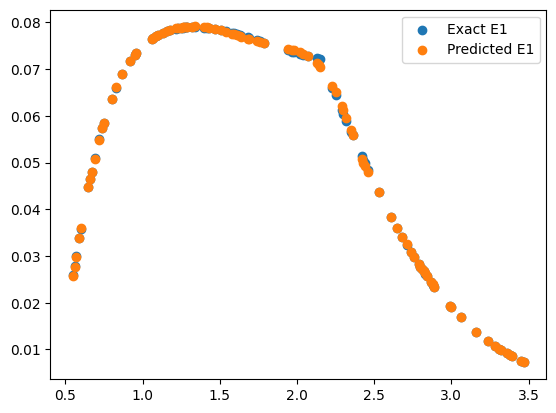

In [36]:
y_hat = lm.predict(X_test)
y_hat = scaler.inverse_transform(y_hat)

mse = np.mean(np.square(y_hat - y_test))
print('Mean Square Error ', mse)

plt.scatter(bond_lengths_test,y_test[:,0], label='Exact E1', marker='o')
plt.scatter(bond_lengths_test, y_hat[:,0], label='Predicted E1', marker='o')
plt.legend()
plt.show()

## Systematic Expressivity Sweep

The main experimental sweep: all circuit families are run across a range of gate counts / degrees / ansatz parameters. For each configuration, `ns` independent reservoir instances are sampled and the MSE is averaged over them.

Three sub-sweeps:
1. **G1/G2/G3**: vary number of gates (depth sweep).
2. **D2_random**: vary expected Erdős–Rényi graph degree.
3. **Scrambling ansatz**: vary \(K\) (scrambler depth) × \(L\) (number of layers).

Results are cached per configuration in `results/quantum_chemistry/`.

In [37]:
import os

LOAD_QRC = True                            # set False to recompute from scratch
QRC_DIR  = os.path.join("results", "qelm", "chemistry", "LiH") 
os.makedirs(QRC_DIR, exist_ok=True)

# ── Experiment config ────────────────────────────────────────────────────────
nqbits_exp = int(np.log2(ground_states.shape[1]))  # log2(ground_states.shape[1]) = log2(256)
nqbits = nqbits_exp # log2(ground_states.shape[1]) = log2(256)
n_shadows = 10000   # number of classical shadows to estimate Renyi-2 entropy
K  =10
ns         = 100    # number of independent random reservoir instances per config
alpha_exp  = 1e-7  # Ridge regularisation (same as existing cells above)

# Target: excitation energies
y_exp = np.zeros((ground_states.shape[0], 2))
y_exp[:, 0] = spectrums[:, 1] - spectrums[:, 0]
y_exp[:, 1] = spectrums[:, 2] - spectrums[:, 0]

# Fixed train/test split — identical indices used for all families
_all_idx = np.arange(ground_states.shape[0])
idx_train_exp, idx_test_exp = train_test_split(_all_idx, test_size=0.33, random_state=42)

# Scaler fitted on train targets once (reused across all runs)
_scaler_exp = MinMaxScaler()
y_train_exp_scaled = _scaler_exp.fit_transform(y_exp[idx_train_exp])

# ── Persistence helpers ──────────────────────────────────────────────────────
def _qrc_path(gates_name, nqbits, ns, depth=None, degree=None,
              n_layers=None, scrambler_depth=None):
    tag = gates_name
    if degree          is not None: tag += f"_deg{degree}"
    if depth           is not None: tag += f"_depth{depth}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(QRC_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")

def _save_qrc(path, obs_res_all, y_hat_all, mse_all, ors,  delta_s, var_x,):
    np.savez_compressed(path,
                        obs_res_all=np.array(obs_res_all),
                        y_hat_all=np.array(y_hat_all),
                        mse_all=np.array(mse_all),
                        ors=np.array(ors),
                        delta_s=np.array(delta_s),
                        var_x=np.array(var_x))
    print(f"  Saved → {path}")

def _load_qrc(path):
    d = np.load(path)
    return d["obs_res_all"], d["y_hat_all"], d["mse_all"], d["ors"], d["delta_s"], d["var_x"]

In [38]:
from tqdm import tqdm 
from metrics import (
    lorentz_curves,
    order_statistics_score,
    renyi2_entropy,
)

def run_qrc_experiment(gates_name, ns=10, **circuit_kwargs):
    """Run ns independent QRC experiments for one circuit family/config.

    Each run:
      1. Builds a new random QuantumCircQiskit reservoir.
      2. Computes quantum features (obs_res) for all 300 ground states.
      3. Fits Ridge regression on the train split.
      4. Evaluates test-set MSE.

    Parameters
    ----------
    gates_name     : str   — circuit family passed to QuantumCircQiskit
    ns             : int   — number of random reservoir instances
    **circuit_kwargs       — forwarded to QuantumCircQiskit (degree, num_gates, etc.)

    Returns
    -------
    obs_res_all : ndarray (ns, 300, n_features)
    y_hat_all   : ndarray (ns, n_test, 2)
    mse_all     : ndarray (ns,)
    """
    obs_res_all, y_hat_all, mse_all = [], [], []
    ors_list, delta_s_list, var_x_list = [], [], []
    for _ in tqdm(range(ns), desc=gates_name, leave=True):
        qrc = QuantumCircQiskit(gates_name, nqbits=nqbits_exp, **circuit_kwargs)

        # LAMBDA
        _, sp, _ = lorentz_curves(qrc.get_reservoir, nqbits, nshots, 1, verbose=False)
        ors = order_statistics_score(sp, D=2**nqbits, K=K)
        #ors = ors[np.isfinite(ors)]
        ors_list.append(ors)
        # DeltaS
        _, delta_s, _ = renyi2_entropy(qrc.get_reservoir, nqbits, n_shadows, 1,
                                            subsystem_size=2, use_statevector=True,
                                            verbose=False)
        delta_s_list.append(delta_s)

        # Quantum features for all 300 ground states
        obs_res = np.array([qrc.run_circuit(gs) for gs in ground_states])
        var_x = np.std(obs_res, axis=0)
        var_x_list.append(var_x)

        obs_train = obs_res[idx_train_exp]
        obs_test  = obs_res[idx_test_exp]

        # Ridge regression on scaled targets
        lm = Ridge(alpha=alpha_exp)
        lm.fit(obs_train, y_train_exp_scaled)

        y_hat = _scaler_exp.inverse_transform(lm.predict(obs_test))
        mse   = np.mean(np.square(y_hat - y_exp[idx_test_exp]))

        obs_res_all.append(obs_res)
        y_hat_all.append(y_hat)
        mse_all.append(mse)

    return np.array(obs_res_all), np.array(y_hat_all), np.array(mse_all), np.array(ors_list), np.array(delta_s_list), np.array(var_x_list)

In [39]:
path = _qrc_path("Haar", nqbits_exp, ns)
if LOAD_QRC and os.path.exists(path):
    print(f"Loading Haar  ← {path}")
    obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
else:
    obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment("Haar", ns=ns)
    _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
results_Haar = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
print(f"  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading Haar  ← results\qelm\chemistry\LiH\Haar_8q_100runs.npz
  MSE = 0.00000037 ± 0.00000002, ORS = -51.4497 ± 1.0983, ΔS = -0.0024 ± 0.0224, Var(X) = 0.0187 ± 0.0118


In [40]:
# ── D2_random: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree = {}

for deg in degrees:
    path = _qrc_path("D2_random", nqbits_exp, ns, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random deg={deg}  ← {path}")
        obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    else:
        obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment("D2_random", ns=ns, degree=deg)
        _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
    results_degree[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading D2_random deg=1  ← results\qelm\chemistry\LiH\D2_random_deg1_8q_100runs.npz
  deg= 1  MSE = 0.00006632 ± 0.00001582, ORS = -122.3539 ± 43.3250, ΔS = 0.8150 ± 0.3670, Var(X) = 0.0333 ± 0.0530
Loading D2_random deg=2  ← results\qelm\chemistry\LiH\D2_random_deg2_8q_100runs.npz
  deg= 2  MSE = 0.00004431 ± 0.00001876, ORS = -90.2282 ± 35.8932, ΔS = 0.5821 ± 0.3641, Var(X) = 0.0249 ± 0.0436
Loading D2_random deg=4  ← results\qelm\chemistry\LiH\D2_random_deg4_8q_100runs.npz
  deg= 4  MSE = 0.00002367 ± 0.00002089, ORS = -61.2952 ± 14.2704, ΔS = 0.2064 ± 0.2607, Var(X) = 0.0141 ± 0.0259
Loading D2_random deg=6  ← results\qelm\chemistry\LiH\D2_random_deg6_8q_100runs.npz


  deg= 6  MSE = 0.00001286 ± 0.00001816, ORS = -52.7915 ± 3.3705, ΔS = 0.0187 ± 0.1266, Var(X) = 0.0091 ± 0.0162
Loading D2_random deg=8  ← results\qelm\chemistry\LiH\D2_random_deg8_8q_100runs.npz
  deg= 8  MSE = 0.00000968 ± 0.00001242, ORS = -51.9362 ± 2.4447, ΔS = -0.0119 ± 0.0801, Var(X) = 0.0094 ± 0.0180
Loading D2_random deg=10  ← results\qelm\chemistry\LiH\D2_random_deg10_8q_100runs.npz
  deg=10  MSE = 0.00000725 ± 0.00000962, ORS = -52.1102 ± 2.6461, ΔS = -0.0122 ± 0.0796, Var(X) = 0.0088 ± 0.0158
Loading D2_random deg=14  ← results\qelm\chemistry\LiH\D2_random_deg14_8q_100runs.npz
  deg=14  MSE = 0.00000685 ± 0.00000860, ORS = -51.8140 ± 1.5234, ΔS = -0.0116 ± 0.0623, Var(X) = 0.0092 ± 0.0166


In [41]:
# ── D2_random: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZ = {}

for deg in degrees:
    path = _qrc_path("D2_random_XZ", nqbits_exp, ns, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random_XZ deg={deg}  ← {path}")
        obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    else:
        obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment("D2_random_XZ", ns=ns, degree=deg)
        _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
    results_degree_XZ[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading D2_random_XZ deg=1  ← results\qelm\chemistry\LiH\D2_random_XZ_deg1_8q_100runs.npz
  deg= 1  MSE = 0.00001707 ± 0.00001933, ORS = -126.7649 ± 43.8696, ΔS = 0.8005 ± 0.3475, Var(X) = 0.0380 ± 0.0477
Loading D2_random_XZ deg=2  ← results\qelm\chemistry\LiH\D2_random_XZ_deg2_8q_100runs.npz
  deg= 2  MSE = 0.00000023 ± 0.00000010, ORS = -88.5706 ± 32.8858, ΔS = 0.4737 ± 0.3227, Var(X) = 0.0263 ± 0.0333
Loading D2_random_XZ deg=4  ← results\qelm\chemistry\LiH\D2_random_XZ_deg4_8q_100runs.npz
  deg= 4  MSE = 0.00000013 ± 0.00000001, ORS = -59.3617 ± 12.4719, ΔS = 0.1024 ± 0.1633, Var(X) = 0.0199 ± 0.0215
Loading D2_random_XZ deg=6  ← results\qelm\chemistry\LiH\D2_random_XZ_deg6_8q_100runs.npz
  deg= 6  MSE = 0.00000012 ± 0.00000001, ORS = -52.2362 ± 3.0214, ΔS = 0.0177 ± 0.0698, Var(X) = 0.0174 ± 0.0156
Loading D2_random_XZ deg=8  ← results\qelm\chemistry\LiH\D2_random_XZ_deg8_8q_100runs.npz
  deg= 8  MSE = 0.00000012 ± 0.00000001, ORS = -52.2115 ± 2.4162, ΔS = 0.0005 ± 0.0303, Var(X)

In [48]:
# ── D2_random_XZY: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZY = {}

for deg in degrees:
    path = _qrc_path("D2_random_XZY", nqbits_exp, ns, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random_XZY deg={deg}  ← {path}")
        obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    else:
        obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment("D2_random_XZY", ns=ns, degree=deg)
        _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
    results_degree_XZY[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading D2_random_XZY deg=1  ← results\qelm\chemistry\LiH\D2_random_XZY_deg1_8q_100runs.npz
  deg= 1  MSE = 0.00000115 ± 0.00000327, ORS = -68.1584 ± 17.2184, ΔS = 0.5884 ± 0.3167, Var(X) = 0.0343 ± 0.0394
Loading D2_random_XZY deg=2  ← results\qelm\chemistry\LiH\D2_random_XZY_deg2_8q_100runs.npz
  deg= 2  MSE = 0.00000013 ± 0.00000002, ORS = -57.7589 ± 8.1747, ΔS = 0.2567 ± 0.2557, Var(X) = 0.0248 ± 0.0257
Loading D2_random_XZY deg=4  ← results\qelm\chemistry\LiH\D2_random_XZY_deg4_8q_100runs.npz
  deg= 4  MSE = 0.00000012 ± 0.00000000, ORS = -51.7071 ± 1.7270, ΔS = 0.0210 ± 0.0429, Var(X) = 0.0189 ± 0.0135
Loading D2_random_XZY deg=6  ← results\qelm\chemistry\LiH\D2_random_XZY_deg6_8q_100runs.npz
  deg= 6  MSE = 0.00000012 ± 0.00000000, ORS = -51.7853 ± 1.5805, ΔS = 0.0064 ± 0.0298, Var(X) = 0.0192 ± 0.0125
Loading D2_random_XZY deg=8  ← results\qelm\chemistry\LiH\D2_random_XZY_deg8_8q_100runs.npz
  deg= 8  MSE = 0.00000012 ± 0.00000000, ORS = -51.5719 ± 1.3229, ΔS = -0.0002 ± 0.0233

In [42]:
# ── G1/G2/G3: sweep number of gates (circuit depth) ─────────────────────────
depths     = [5, 10, 50, 100, 500, 1000, 2000]
g_families = ["G1", "G2", "G3"]
results_depth = {f: {} for f in g_families}

for family in g_families:
    for depth in depths:
        path = _qrc_path(family, nqbits_exp, ns, depth=depth)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading {family} depth={depth}  ← {path}")
            obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
            ors[ors<-254] = -254
        else:
            obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment(family, ns=ns, num_gates=depth)
            _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
        results_depth[family][depth] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
        print(f"  {family} depth={depth:4d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading G1 depth=5  ← results\qelm\chemistry\LiH\G1_depth5_8q_100runs.npz
  G1 depth=   5  MSE = 0.00005808 ± 0.00002391, ORS = -253.0475 ± 9.4772, ΔS = 1.2704 ± 0.2003, Var(X) = 0.0388 ± 0.0730
Loading G1 depth=10  ← results\qelm\chemistry\LiH\G1_depth10_8q_100runs.npz
  G1 depth=  10  MSE = 0.00004891 ± 0.00002312, ORS = -228.9925 ± 51.5401, ΔS = 1.1984 ± 0.2735, Var(X) = 0.0367 ± 0.0706
Loading G1 depth=50  ← results\qelm\chemistry\LiH\G1_depth50_8q_100runs.npz
  G1 depth=  50  MSE = 0.00014312 ± 0.00011956, ORS = -119.6524 ± 62.9844, ΔS = 0.5666 ± 0.5042, Var(X) = 0.0182 ± 0.0505
Loading G1 depth=100  ← results\qelm\chemistry\LiH\G1_depth100_8q_100runs.npz
  G1 depth= 100  MSE = 0.00027302 ± 0.00015979, ORS = -122.8556 ± 68.9441, ΔS = 0.1305 ± 0.3227, Var(X) = 0.0080 ± 0.0345
Loading G1 depth=500  ← results\qelm\chemistry\LiH\G1_depth500_8q_100runs.npz
  G1 depth= 500  MSE = 0.00035512 ± 0.00016254, ORS = -135.6216 ± 74.6224, ΔS = -0.0147 ± 0.1663, Var(X) = 0.0042 ± 0.0256
Loading 

In [43]:
# ── Scrambling ansatz: sweep K (scrambler depth) and L (n_layers) ────────────
K_values = [1, 2, 3, 5, 6, 7, 8]
L_values = [1, 2, 3, 5, 6, 7, 8]
results_scrambling = {}

for L_val in L_values:
    for K_val in K_values:
        path = _qrc_path("scrambling_ansatz", nqbits_exp, ns,
                         n_layers=L_val, scrambler_depth=K_val)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading scrambling_ansatz L={L_val} K={K_val}  ← {path}")
            obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
        else:
            obs, y_hat, mse, ors, delta_s, var_x  = run_qrc_experiment(
                "scrambling_ansatz", ns=ns,
                n_layers=L_val, scrambler_depth=K_val
            )
            _save_qrc(path, obs, y_hat, mse, ors, delta_s, var_x)
        results_scrambling[(L_val, K_val)] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
        print(f"  L={L_val} K={K_val}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading scrambling_ansatz L=1 K=1  ← results\qelm\chemistry\LiH\scrambling_ansatz_L1_K1_8q_100runs.npz
  L=1 K=1  MSE = 0.00001856 ± 0.00000067, ORS = -98.5256 ± 28.9478, ΔS = 1.3313 ± 0.0210, Var(X) = 0.0393 ± 0.0407
Loading scrambling_ansatz L=1 K=2  ← results\qelm\chemistry\LiH\scrambling_ansatz_L1_K2_8q_100runs.npz
  L=1 K=2  MSE = 0.00000149 ± 0.00000059, ORS = -81.5897 ± 20.0769, ΔS = 0.8658 ± 0.1862, Var(X) = 0.0367 ± 0.0326
Loading scrambling_ansatz L=1 K=3  ← results\qelm\chemistry\LiH\scrambling_ansatz_L1_K3_8q_100runs.npz
  L=1 K=3  MSE = 0.00000055 ± 0.00000009, ORS = -71.4321 ± 14.0445, ΔS = 0.8617 ± 0.2075, Var(X) = 0.0320 ± 0.0287
Loading scrambling_ansatz L=1 K=5  ← results\qelm\chemistry\LiH\scrambling_ansatz_L1_K5_8q_100runs.npz
  L=1 K=5  MSE = 0.00000043 ± 0.00000003, ORS = -64.1438 ± 10.2102, ΔS = 0.5849 ± 0.1675, Var(X) = 0.0266 ± 0.0220
Loading scrambling_ansatz L=1 K=6  ← results\qelm\chemistry\LiH\scrambling_ansatz_L1_K6_8q_100runs.npz
  L=1 K=6  MSE = 0.000000

In [44]:
# ── Metric helpers shared by all within-family plot cells ────────────────
METRIC_LABELS_QRC = [
    ('ors_1d',     r'$\Lambda$ (order-statistics)'),
    ('delta_s_1d', r'$\Delta S$ (Rényi-2 entropy)'),
    ('var_x_1d',   r'$\mathrm{Var}_x[\langle O\rangle_x]$ (input sensitivity)'),
    ('mse',        'Test MSE'),
]

def _scalar_metrics(r):
    # ors and delta_s stored as (ns, 1); var_x as (ns, n_features)
    return {
        'ors_1d':     r['ors'][:, 0],
        'delta_s_1d': r['delta_s'][:, 0],
        'var_x_1d':   r['var_x'].mean(axis=1),
        'mse':        r['mse'],
    }

print('Metric helpers defined.')


Metric helpers defined.


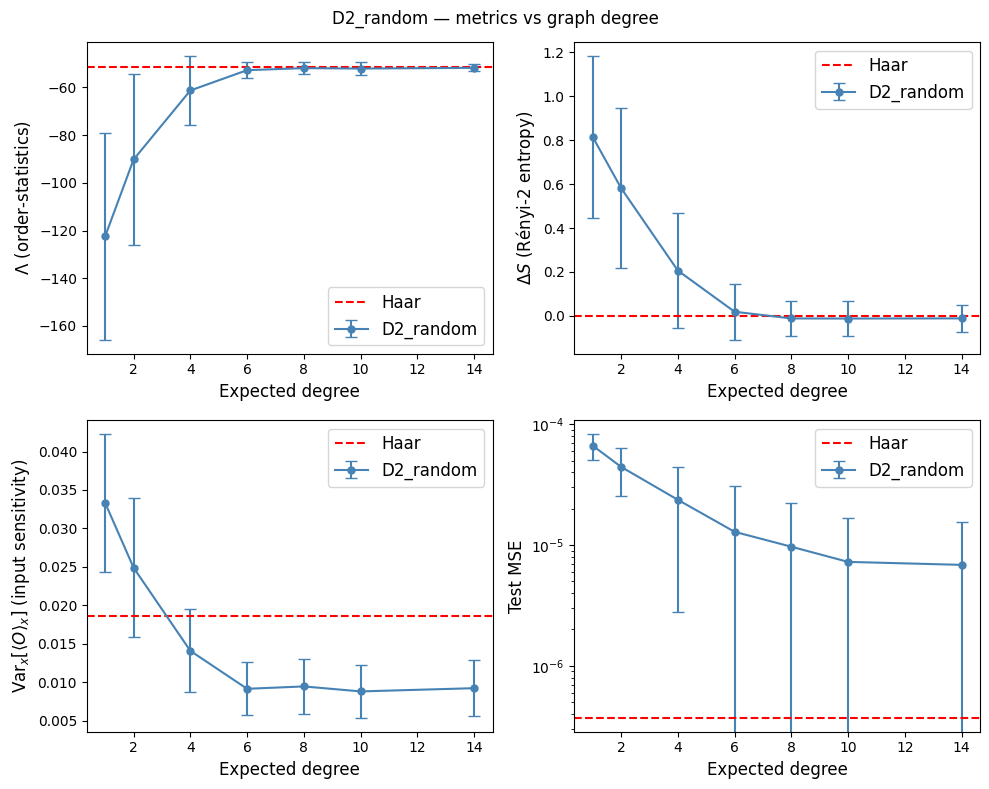

In [45]:
# ── D2_random: 4-panel metrics vs expected degree ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (key, label) in zip(axes.flatten(), METRIC_LABELS_QRC):
    means = np.array([_scalar_metrics(results_degree[d])[key].mean() for d in degrees])
    stds  = np.array([_scalar_metrics(results_degree[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(_scalar_metrics(results_Haar)[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.legend(fontsize=12)

    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    if key == 'mse':
        ax.set_yscale('log')
fig.suptitle('D2_random — metrics vs graph degree', fontsize=12)
plt.tight_layout()
plt.show()


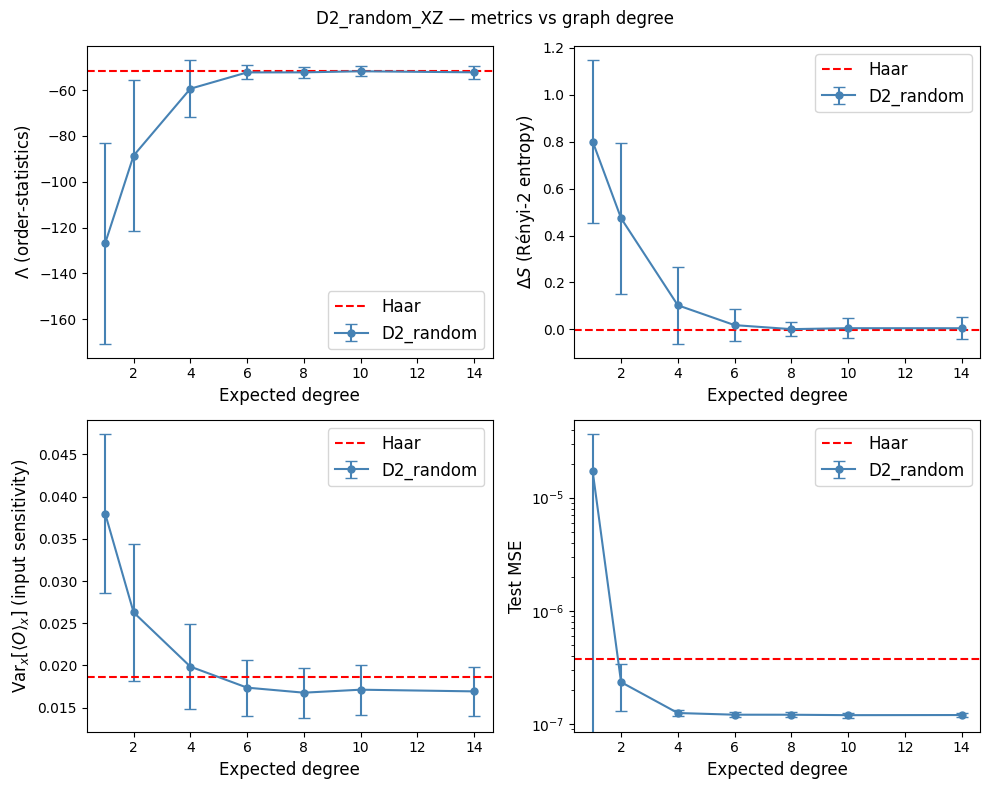

In [46]:
# ── D2_random_XZ: 4-panel metrics vs expected degree ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (key, label) in zip(axes.flatten(), METRIC_LABELS_QRC):
    means = np.array([_scalar_metrics(results_degree_XZ[d])[key].mean() for d in degrees])
    stds  = np.array([_scalar_metrics(results_degree_XZ[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(_scalar_metrics(results_Haar)[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.legend(fontsize=12)

    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    if key == 'mse':
        ax.set_yscale('log')
fig.suptitle('D2_random_XZ — metrics vs graph degree', fontsize=12)
plt.tight_layout()
plt.show()


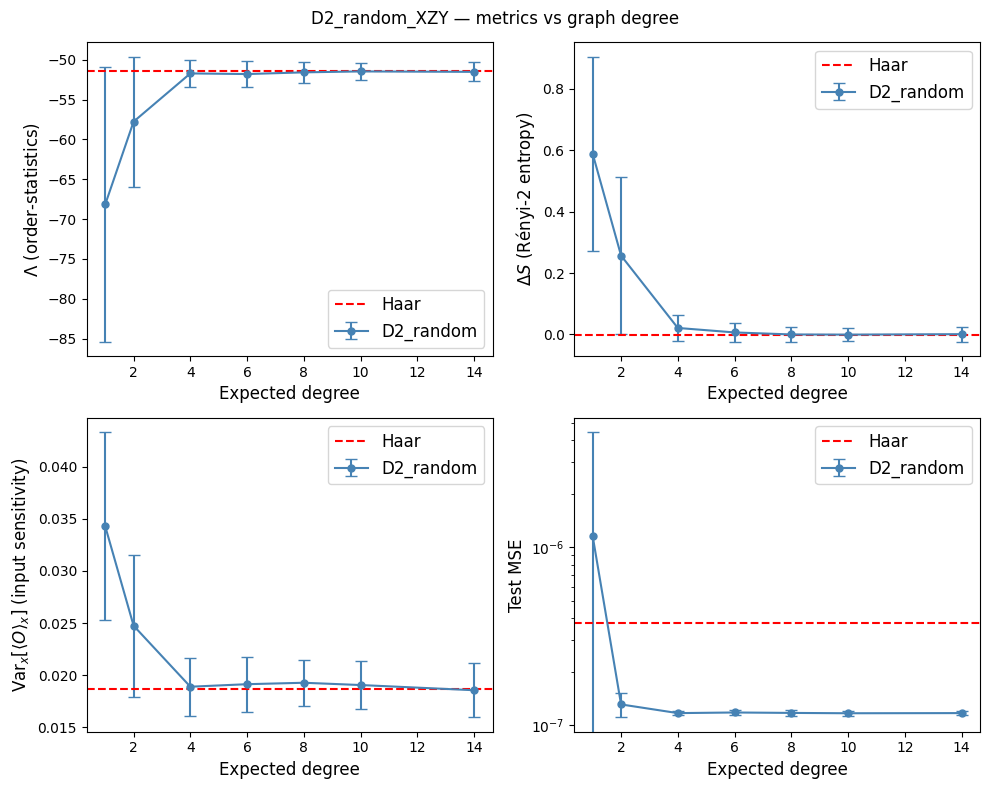

In [49]:
# ── D2_random_XZY: 4-panel metrics vs expected degree ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (key, label) in zip(axes.flatten(), METRIC_LABELS_QRC):
    means = np.array([_scalar_metrics(results_degree_XZY[d])[key].mean() for d in degrees])
    stds  = np.array([_scalar_metrics(results_degree_XZY[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(_scalar_metrics(results_Haar)[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.legend(fontsize=12)

    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    if key == 'mse':
        ax.set_yscale('log')
fig.suptitle('D2_random_XZY — metrics vs graph degree', fontsize=12)
plt.tight_layout()
plt.show()


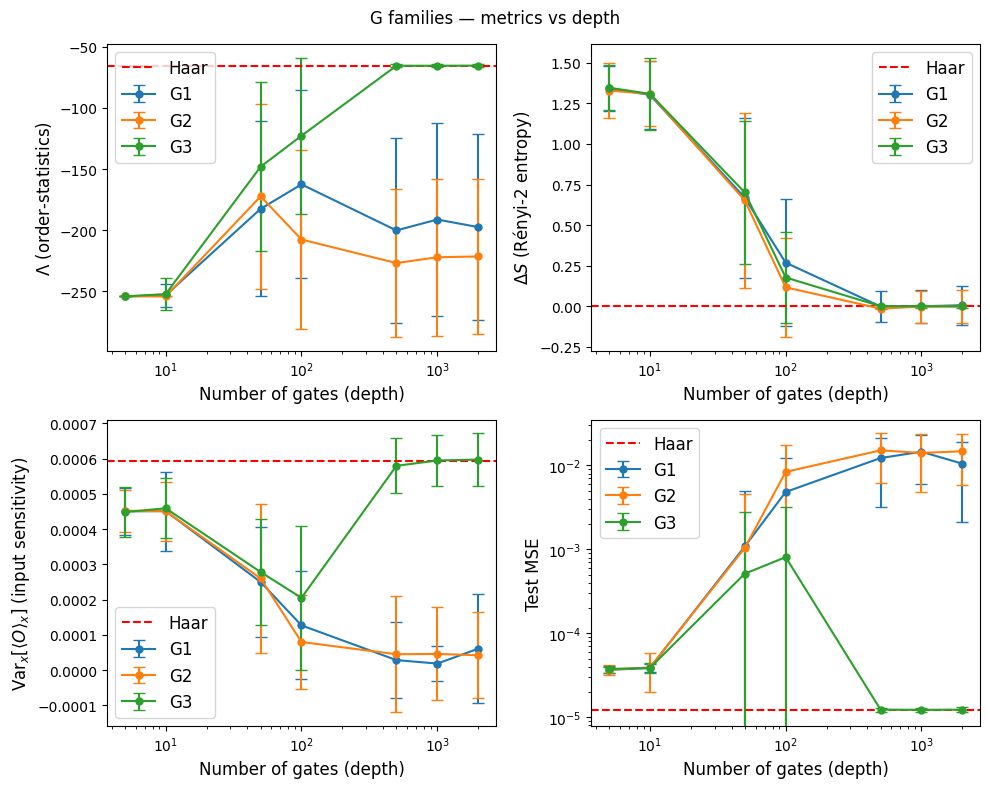

In [105]:
# ── G1/G2/G3: 4-panel metrics vs circuit depth ───────────────────────────────
colors_g = {"G1": "tab:blue", "G2": "tab:orange", "G3": "tab:green"}
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, (key, label) in zip(axes.flatten(), METRIC_LABELS_QRC):
    for family in g_families:
        means = np.array([_scalar_metrics(results_depth[family][d])[key].mean() for d in depths])
        stds  = np.array([_scalar_metrics(results_depth[family][d])[key].std()  for d in depths])
        ax.errorbar(depths, means, yerr=stds, fmt='o-', color=colors_g[family],
                    capsize=4, lw=1.5, ms=5, label=family)
    ax.axhline(_scalar_metrics(results_Haar)[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xscale('log')
    ax.set_xlabel('Number of gates (depth)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=12)
    if key == 'mse':
        ax.set_yscale('log')
fig.suptitle('G families — metrics vs depth', fontsize=12)
plt.tight_layout()
plt.show()


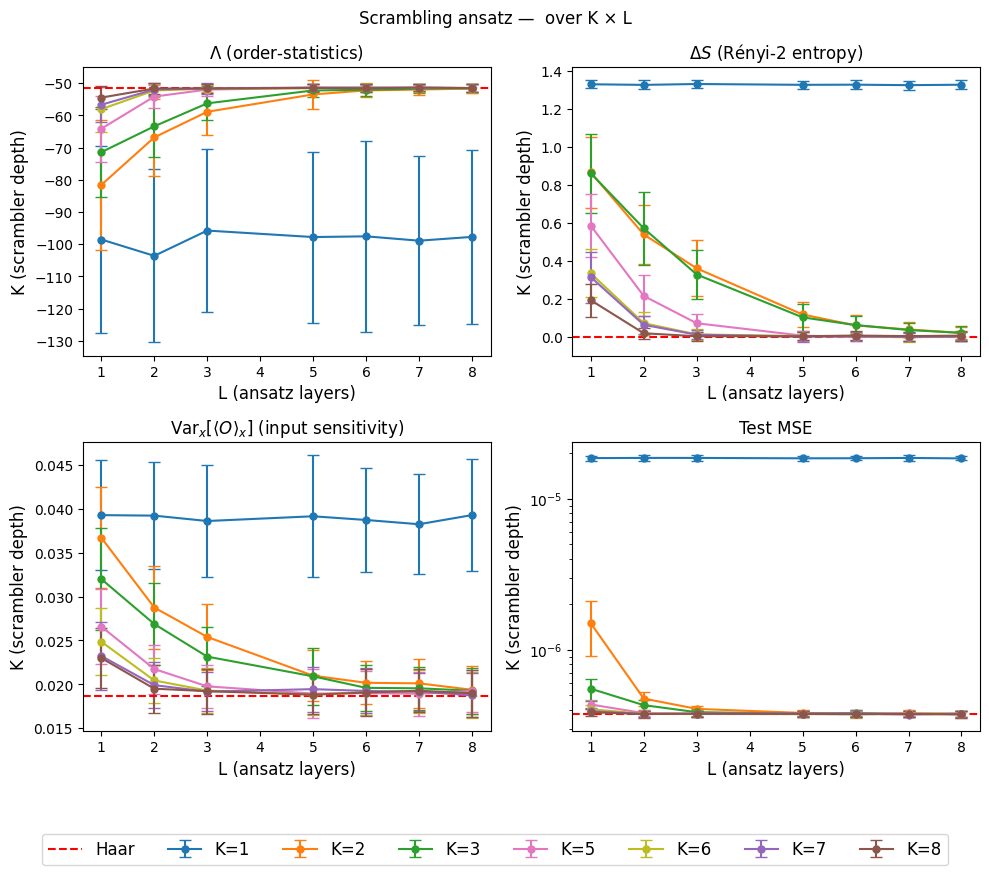

In [62]:
# ── Scrambling ansatz: 4 heatmaps over K × L ─────────────────────────────────
K_arr = np.array(K_values)
L_arr = np.array(L_values)
len_K = list(range(len(K_values)))
colors_g = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 5: "tab:pink", 6: "tab:olive", 7: "tab:purple", 8: "tab:brown"}


fig, axes = plt.subplots(2, 2, figsize=(10,8))
for ax, (key, label) in zip(axes.flatten(), METRIC_LABELS_QRC):
    grid_mean = np.array([[_scalar_metrics(results_scrambling[(L_v, K_v)])[key].mean()
                      for L_v in L_values]
                     for K_v in K_values])
    grid_std = np.array([[_scalar_metrics(results_scrambling[(L_v, K_v)])[key].std()    
                      for L_v in L_values]
                     for K_v in K_values])

    # results_scrambling keyed by (L_val, K_val); rows=K, cols=L
    for K_val in K_values:
        ax.errorbar(L_values, grid_mean[K_values.index(K_val), :], yerr=grid_std[K_values.index(K_val), :], fmt='o-', color=colors_g[K_val],
                    capsize=4, lw=1.5, ms=5, label='K=' + str(K_val))
    ax.axhline(_scalar_metrics(results_Haar)[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('L (ansatz layers)', fontsize=12)
    ax.set_ylabel('K (scrambler depth)', fontsize=12)
    ax.set_title(label, fontsize=12)
    if key == 'mse':
        ax.set_yscale('log')
axes[1,1].legend(fontsize=12, ncols=3)
handles, labels_ = axes[1,1].get_legend_handles_labels()
axes[1,1].get_legend().remove()
fig.legend(handles, labels_, loc='lower center', ncol=8, fontsize=12,
           bbox_to_anchor=(0.5, -0.1))

fig.suptitle('Scrambling ansatz —  over K × L', fontsize=12)
plt.tight_layout()
plt.show()


## Feature Richness Evaluation — Effective Rank and Graph Analysis

Beyond MSE, we characterise the **richness** of the feature matrix produced by each reservoir:
- **Effective rank \(R_{\mathrm{eff}}\)** — participation ratio of singular values. Measures how many independent dimensions the reservoir spans in the observable space.
- **Graph-based analysis** — connectivity and spectral properties of the observable correlation matrix.

A high \(R_{\mathrm{eff}}\) is necessary for good QELM performance; low \(R_{\mathrm{eff}}\) means the reservoir is projecting inputs into a low-dimensional subspace, limiting the regressor's ability to fit the energy curves.

In [21]:
def get_nodes(o):
    fft_c1 = np.fft.rfft(o)
    mags_c1 = np.abs(fft_c1)
    thresh_c1 = 0.2 * mags_c1.max()
    n_modes_c1 = int(np.sum(mags_c1 > thresh_c1))
    return n_modes_c1

richeness_Haar = [[get_nodes(results_Haar['obs_res'][s][i]) for s in range(ns)] for i in range(24)]
richeness_Haar_mean = np.mean(richeness_Haar)
richeness_Haar_std = np.std(richeness_Haar)

richeness_Haar_mean, richeness_Haar_std

(np.float64(11.280833333333334), np.float64(1.2580935201945664))

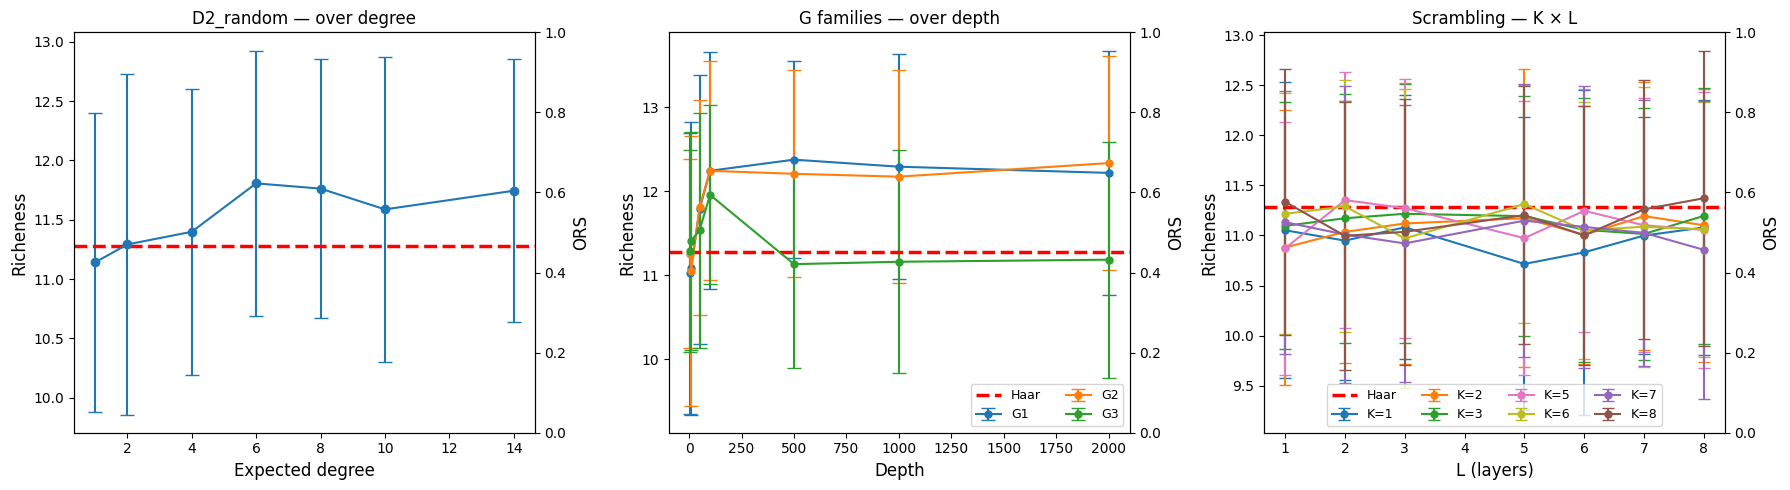

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. D2_random (degree) ─────────────────────────────────────────────
ax = axes[0]
ax2 = ax.twinx()

# Richeness
mean_rich = np.mean([[[get_nodes(results_degree[d]['obs_res'][s][i]) 
                       for s in range(ns)] for i in range(24)] 
                     for d in degrees], axis=(1,2))

std_rich = np.std([[[get_nodes(results_degree[d]['obs_res'][s][i]) 
                      for s in range(ns)] for i in range(24)] 
                    for d in degrees], axis=(1,2))

ax.errorbar(degrees, mean_rich, yerr=std_rich, fmt='o-', capsize=5, label='Richeness')
ax.axhline(richeness_Haar_mean, color='red', lw=2.5, ls='--', label='Haar')

# ORS
means = np.array([_scalar_metrics(results_degree[d])['ors_1d'].mean() for d in degrees])
stds  = np.array([_scalar_metrics(results_degree[d])['ors_1d'].std()  for d in degrees])

#ax2.errorbar(degrees, means, yerr=stds, fmt='s--', color='steelblue',
#             capsize=4, lw=1.5, ms=5)

ax.set_xlabel('Expected degree', fontsize=12)
ax.set_ylabel('Richeness', fontsize=12)
ax2.set_ylabel('ORS', fontsize=12)
ax.set_title('D2_random — over degree', fontsize=12)


# ── 2. G families (depth) ─────────────────────────────────────────────
ax = axes[1]
ax2 = ax.twinx()

colors_g = {"G1": "tab:blue", "G2": "tab:orange", "G3": "tab:green"}

for family in g_families:
    # Richeness
    mean_rich = np.mean([[[get_nodes(results_depth[family][d]['obs_res'][s][i]) 
                           for s in range(ns)] for i in range(24)] 
                         for d in depths], axis=(1,2))

    std_rich = np.std([[[get_nodes(results_depth[family][d]['obs_res'][s][i]) 
                          for s in range(ns)] for i in range(24)] 
                        for d in depths], axis=(1,2))

    ax.errorbar(depths, mean_rich, yerr=std_rich, fmt='o-',
                capsize=5, color=colors_g[family], lw=1.5, ms=5, label=f'{family}')

    # ORS
    means = np.array([_scalar_metrics(results_depth[family][d])['ors_1d'].mean() for d in depths])
    stds  = np.array([_scalar_metrics(results_depth[family][d])['ors_1d'].std()  for d in depths])

    #ax2.errorbar(depths, means, yerr=stds, fmt='s--',
    #             color=colors_g[family], lw=1.5, ms=5, alpha=0.7, label=f'{family} ')

ax.axhline(richeness_Haar_mean, color='red', lw=2.5, ls='--', label='Haar')
ax.legend(fontsize=9, ncol=2)
ax.set_xlabel('Depth', fontsize=12)
ax.set_ylabel('Richeness', fontsize=12)
ax2.set_ylabel('ORS', fontsize=12)
ax.set_title('G families — over depth', fontsize=12)


# ── 3. Scrambling (K × L) ─────────────────────────────────────────────
ax = axes[2]
ax2 = ax.twinx()

colors_scrambling = {1: "tab:blue", 2: "tab:orange", 3: "tab:green",
                     5: "tab:pink", 6: "tab:olive", 7: "tab:purple", 8: "tab:brown"}

L_values = [1, 2, 3, 5, 6, 7, 8]
K_values = [1, 2, 3, 5, 6, 7, 8]

# Richeness
grid_mean = np.mean([[[[get_nodes(results_scrambling[(L_v, K_v)]['obs_res'][s][i]) 
                         for s in range(ns)] for i in range(24)] 
                       for L_v in L_values]
                     for K_v in K_values], axis=(2,3))

grid_std = np.std([[[[get_nodes(results_scrambling[(L_v, K_v)]['obs_res'][s][i]) 
                        for s in range(ns)] for i in range(24)] 
                      for L_v in L_values]
                    for K_v in K_values], axis=(2,3))

for K_val in K_values:
    idx = K_values.index(K_val)

    # Richeness
    ax.errorbar(L_values, grid_mean[idx, :], yerr=grid_std[idx, :],
                fmt='o-', color=colors_scrambling[K_val],
                capsize=4, lw=1.5, ms=5, label=f'K={K_val}')

    # ORS
    means = np.array([_scalar_metrics(results_scrambling[(L_v, K_val)])['ors_1d'].mean()
                      for L_v in L_values])
    stds  = np.array([_scalar_metrics(results_scrambling[(L_v, K_val)])['ors_1d'].std()
                      for L_v in L_values])

    #ax2.errorbar(L_values, means, yerr=stds,
    #             fmt='s--', color=colors_scrambling[K_val],
    #             lw=1.5, ms=5, alpha=0.7, label=f'K={K_val}')

ax.axhline(richeness_Haar_mean, color='red', lw=2.5, ls='--', label='Haar')
ax.legend(fontsize=9, ncol=4)
ax.set_xlabel('L (layers)', fontsize =12)
ax.set_ylabel('Richeness', fontsize =12)
ax2.set_ylabel('ORS', fontsize =12)
ax.set_title('Scrambling — K × L', fontsize =12)


# ── Layout ───────────────────────────────────────────────────────────
plt.tight_layout()
plt.show()

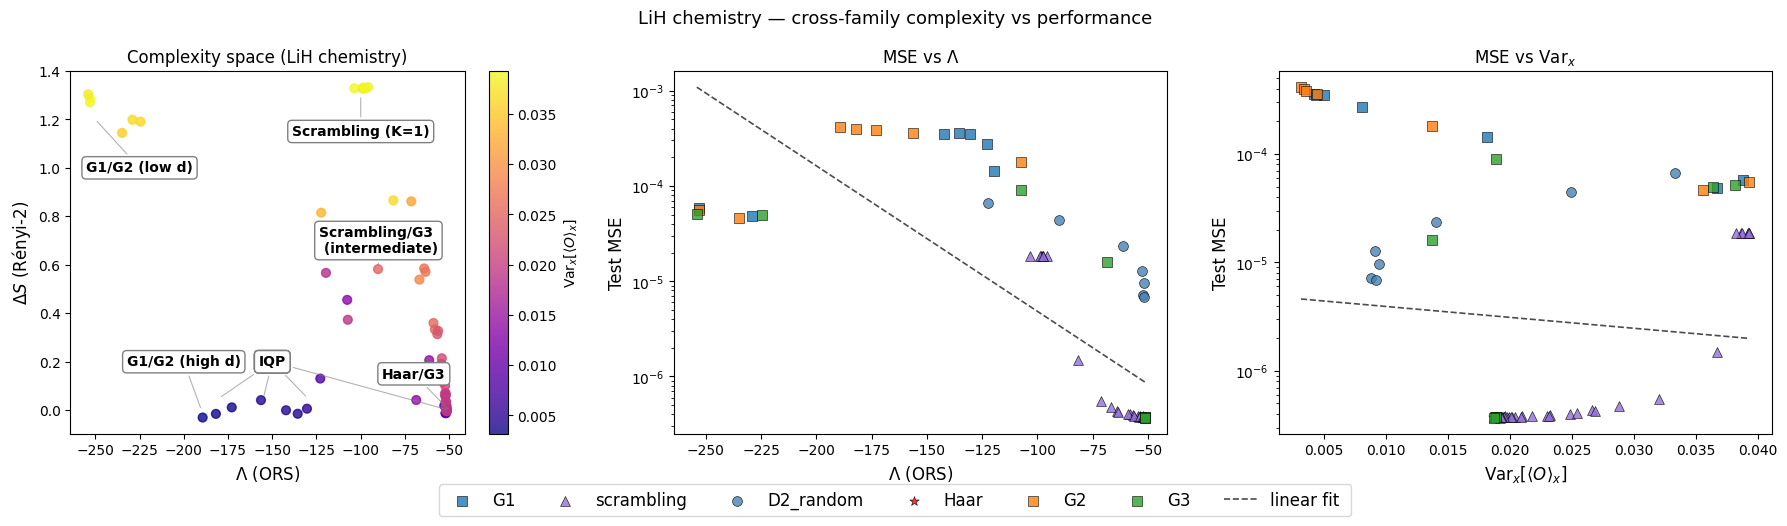


Correlation summary (LiH chemistry):
  log(MSE) vs Λ:       R² = 0.587, slope = -0.015
  log(MSE) vs Var_x:   R² = 0.008, slope = -10.060


In [173]:
from scipy import stats

# ── Cross-family scatter: complexity vs performance (QRC chemistry) ──────────
# Build flat list: one point per (family, hyperparameter) configuration
_pts_chem = []

def _get_metrics(r):
    """Return (ors_mean, delta_s_mean, var_x_mean, mse_mean) from a result dict."""
    m = _scalar_metrics(r)
    return {
        'ors':     m['ors_1d'].mean(),
        'delta_s': m['delta_s_1d'].mean(),
        'var_x':   m['var_x_1d'].mean(),
        'mse':     m['mse'].mean(),
    }

# Haar
m = _get_metrics(results_Haar)
_pts_chem.append({'family': 'Haar', 'label': 'Haar', **m})

# D2_random
for deg in degrees:
    m = _get_metrics(results_degree[deg])
    _pts_chem.append({'family': 'D2_random', 'label': f'D2 d={deg}', **m})

# G families
for family in g_families:
    for depth in depths:
        m = _get_metrics(results_depth[family][depth])
        _pts_chem.append({'family': family, 'label': f'{family} d={depth}', **m})

# Scrambling
for L_val in L_values:
    for K_val in K_values:
        m = _get_metrics(results_scrambling[(L_val, K_val)])
        _pts_chem.append({'family': 'scrambling', 'label': f'Sc L={L_val} K={K_val}', **m})


_family_colors = {'Haar': 'red', 'D2_random': 'steelblue',
                  'G1': 'tab:blue', 'G2': 'tab:orange', 'G3': 'tab:green',
                  'scrambling': 'mediumpurple'}
_marker = {'Haar': '*', 'D2_random': 'o', 'G1': 's', 'G2': 's', 'G3': 's',
           'scrambling': '^'}

ors_arr   = np.array([p['ors']     for p in _pts_chem])
ds_arr    = np.array([p['delta_s'] for p in _pts_chem])
vx_arr    = np.array([p['var_x']   for p in _pts_chem])
mse_arr   = np.array([p['mse']     for p in _pts_chem])

# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── Panel 1: Complexity space coloured by Var_x ────────────────────────────
ax = axes[0]
sc_plot = ax.scatter(ors_arr, ds_arr, c=vx_arr, cmap='plasma', s=40, alpha=0.8)
plt.colorbar(sc_plot, ax=ax, label=r'$\mathrm{Var}_x[\langle O\rangle_x]$')
ax.set_xlabel(r'$\Lambda$ (ORS)', fontsize=12)
ax.set_ylabel(r'$\Delta S$ (Rényi-2)', fontsize=12)
ax.set_title('Complexity space (LiH chemistry)', fontsize=12)

# Compute mean position per family for annotations
fam_positions = {}
for fam in set(p['family'] for p in _pts_chem):
    idx = [j for j, p in enumerate(_pts_chem) if p['family'] == fam]
    fam_positions[fam] = (ors_arr[idx].mean(), ds_arr[idx].mean())


ax.annotate('IQP', xy=(-155, 0.05), xytext=(-150, 0.2),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))
ax.annotate('IQP', xy=(-130, 0.05), xytext=(-150, 0.2),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))
ax.annotate('IQP', xy=(-180, 0.05), xytext=(-150, 0.2),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))
ax.annotate('IQP', xy=(-50, 0.0), xytext=(-150, 0.2),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

ax.annotate('Haar/G3', xy=(-50, 0.0), xytext=(-70, 0.15),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

ax.annotate('G1/G2 (low d)', xy=(-250, 1.2), xytext=(-225, 1),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

ax.annotate('G1/G2 (high d)', xy=(-190, 0.0), xytext=(-200, 0.2),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

ax.annotate('Scrambling (K=1)', xy=(-100, 1.3), xytext=(-100, 1.15),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

ax.annotate('Scrambling/G3 \n (intermediate)', xy=(-90, 0.6), xytext=(-90, 0.7),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))

# ─── Panel 2: MSE vs Λ with trend + R² ──────────────────────────────────────
ax = axes[1]
for fam in set(p['family'] for p in _pts_chem):
    idx = [j for j, p in enumerate(_pts_chem) if p['family'] == fam]
    ax.scatter(ors_arr[idx], mse_arr[idx], color=_family_colors[fam],
               marker=_marker[fam], s=50, alpha=0.8, label=fam,
               edgecolor='black', lw=0.5)

slope, intercept, r_val, p_val, _ = stats.linregress(ors_arr, np.log10(mse_arr))
x_fit = np.linspace(ors_arr.min(), ors_arr.max(), 100)
y_fit = 10 ** (slope * x_fit + intercept)
ax.plot(x_fit, y_fit, 'k--', lw=1.2, alpha=0.7,
        label=f'linear fit ($R^2$={r_val**2:.2f})')

ax.set_xlabel(r'$\Lambda$ (ORS)', fontsize=12)
ax.set_ylabel('Test MSE', fontsize=12)
ax.set_title(r'MSE vs $\Lambda$', fontsize=12)
ax.set_yscale('log')

# ─── Panel 3: MSE vs Var_x with trend + R² ──────────────────────────────────
ax = axes[2]
for fam in set(p['family'] for p in _pts_chem):
    idx = [j for j, p in enumerate(_pts_chem) if p['family'] == fam]
    ax.scatter(vx_arr[idx], mse_arr[idx], color=_family_colors[fam],
               marker=_marker[fam], s=50, alpha=0.8, label=fam,
               edgecolor='black', lw=0.5)

slope_v, intercept_v, r_val_v, _, _ = stats.linregress(vx_arr, np.log10(mse_arr))
x_fit = np.linspace(vx_arr.min(), vx_arr.max(), 100)
y_fit = 10 ** (slope_v * x_fit + intercept_v)
ax.plot(x_fit, y_fit, 'k--', lw=1.2, alpha=0.7,
        label=f'linear fit ')

ax.set_xlabel(r'$\mathrm{Var}_x[\langle O\rangle_x]$', fontsize=12)
ax.set_ylabel('Test MSE', fontsize=12)
ax.set_title(r'MSE vs Var$_x$', fontsize=12)
ax.set_yscale('log')

# ─── Single shared legend below ─────────────────────────────────────────────
handles, labels_ = axes[2].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=8, fontsize=12,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle('LiH chemistry — cross-family complexity vs performance', fontsize=13)
plt.tight_layout()
plt.show()

# Print correlations
print(f"\nCorrelation summary (LiH chemistry):")
print(f"  log(MSE) vs Λ:       R² = {r_val**2:.3f}, slope = {slope:.3f}")
print(f"  log(MSE) vs Var_x:   R² = {r_val_v**2:.3f}, slope = {slope_v:.3f}")

In [23]:
# Ramon Valdric

In [24]:
import os
import itertools

# ── Parameters ──────────────────────────────────────────────────────────────
nqbits = 10
ns     = 100
alpha  = "1e-12"
OUT    = os.path.join("experiments", "chemistry", "parameters.txt")

# Sweeps (must match the notebook cells exactly)
degrees_sweep  = [1, 2, 3, 4, 5, 6, 8, 10, 14]          # D2_random
depths_sweep   = [5, 10, 50, 20, 100, 200, 500, 1000, 2000]  # G1/G2/G3
g_families     = ["G1", "G2", "G3"]
K_values       = [1, 2, 3, 4, 5, 6, 7, 8]               # scrambling_ansatz
L_values       = [1, 2, 3, 4, 5, 6, 7, 8]    

# ── Build rows ───────────────────────────────────────────────────────────────
# Column order: nqbits ns alpha gates_name degree depth scrambler_K scrambler_layers
rows = []
def row(gates_name, degree=-1, depth=-1, K=-1, L=-1):
    return f"{nqbits} {ns} {alpha} {gates_name} {degree} {depth} {K} {L}"

# Haar (single baseline)
rows.append(row("Haar"))

# D2_random — degree sweep
for deg in degrees_sweep:
    rows.append(row("D2_random", degree=deg))

# G1/G2/G3 — depth sweep
for family, depth in itertools.product(g_families, depths_sweep):
    rows.append(row(family, depth=depth))

# Scrambling ansatz — L × K grid
for L_val, K_val in itertools.product(L_values, K_values):
    rows.append(row("scrambling_ansatz", K=K_val, L=L_val))

# ── Write file ───────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUT), exist_ok=True)
with open(OUT, "w") as f:
    f.write("\n".join(rows) + "\n")

print(f"Written {len(rows)} configurations → {OUT}")


Written 101 configurations → experiments\chemistry\parameters.txt


## Appendix: Toy Experiment with Classical Amplitude Encoding

A controlled toy experiment using classical randomly generated states (not LiH wavefunctions) as inputs to the reservoir. This validates the QELM pipeline end-to-end and characterises how performance scales with the number of input features and circuit depth, independently of the molecular physics.

In [63]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from qiskit.quantum_info import SparsePauliOp
import matplotlib.pyplot as plt
from tqdm import tqdm
from QELM import QuantumCircQiskit

# ── Target function ──────────────────────────────────────────────
def generate_target(x, n_a=6, seed=0):
    rng = np.random.default_rng(seed)
    K = (3**n_a - 1) // 2
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    y = np.zeros_like(x)
    for k in range(K + 1):
        y += a[k] * np.cos(k * x) + b[k] * np.sin(k * x)
    return y


# ── Random Pauli observables ─────────────────────────────────────
def random_pauli_observables(n_obs, n_qubits, seed=42):
    rng = np.random.default_rng(seed)
    paulis = np.array(['I', 'X', 'Y', 'Z'])
    return [SparsePauliOp(''.join(rng.choice(paulis, size=n_qubits)))
            for _ in range(n_obs)]

Computing Pauli features...
Computing Exponential features...


Targets: 100%|██████████| 20/20 [01:57<00:00,  5.86s/it]


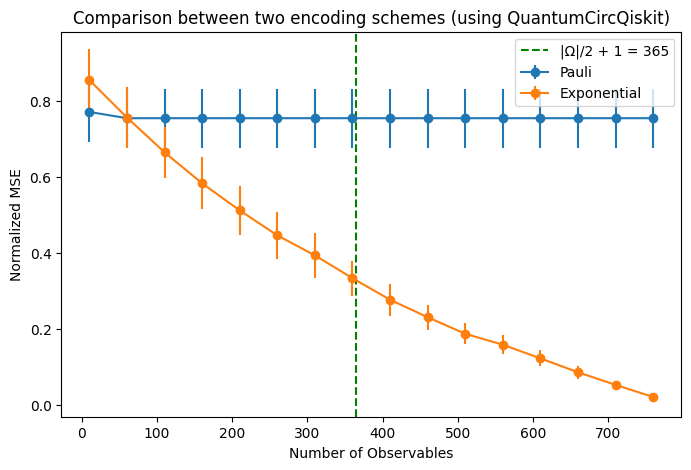

In [64]:
n_samples = 5000
n_a = 4
nqbits = 6
n_targets = 20

x = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)

n_obs_list = np.arange(10, 800, 50)  # number of observables to use (sweep)
# Build max observable set once; smaller sets are subsets of this
max_n_obs = max(n_obs_list)
all_observables = random_pauli_observables(max_n_obs, nqbits, seed=42)

# ── Build ONE QRC per encoding, with the MAX observable set ───
np.random.seed(42)
qrc_pauli = QuantumCircQiskit(
    'RandomRotation', nqbits=nqbits, encoding='pauli',
    theta_scale=1.0, statevector=True,
    observables_type=all_observables,
)

np.random.seed(42)   # same seed → same reservoir
qrc_exp = QuantumCircQiskit(
    'RandomRotation', nqbits=nqbits, encoding='exponential', k_exp=nqbits,
    theta_scale=1.0, statevector=True,
    observables_type=all_observables,
)

# ── Compute all features ONCE per encoding ──────────────────
print("Computing Pauli features...")
#qrc_exp._U_res = None
#qrc_pauli._U_res = None
features_pauli = qrc_pauli.feature_matrix(x)#np.array([qrc_pauli.run_circuit(xi) for xi in tqdm(x)])
print("Computing Exponential features...")
features_exp = qrc_exp.feature_matrix(x) #np.array([qrc_exp.run_circuit(xi) for xi in tqdm(x)])
# Train/test split (same indices for everything)
idx_train, idx_test = train_test_split(
    np.arange(n_samples), test_size=0.3, random_state=42
)

mse_pauli = np.zeros((n_targets, len(n_obs_list)))
mse_exp   = np.zeros((n_targets, len(n_obs_list)))

for t in tqdm(range(n_targets), desc="Targets"):
    y = generate_target(x, n_a=n_a, seed=t)
    y_train, y_test = y[idx_train], y[idx_test]
    
    for i, n_obs in enumerate(n_obs_list):
        # Subset features: first n_obs columns
        f_p_train = features_pauli[idx_train, :n_obs]
        f_p_test  = features_pauli[idx_test,  :n_obs]
        f_e_train = features_exp[idx_train, :n_obs]
        f_e_test  = features_exp[idx_test,  :n_obs]
        
        lm_p = LinearRegression().fit(f_p_train, y_train)
        lm_e = LinearRegression().fit(f_e_train, y_train)
        
        mse_pauli[t, i] = np.mean((lm_p.predict(f_p_test) - y_test)**2)
        mse_exp[t, i]   = np.mean((lm_e.predict(f_e_test) - y_test)**2)

max_mse = max(mse_pauli.max(), mse_exp.max())
mse_pauli_norm = mse_pauli / max_mse
mse_exp_norm   = mse_exp / max_mse

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(n_obs_list, mse_pauli_norm.mean(axis=0),
            yerr=mse_pauli_norm.std(axis=0), label='Pauli', marker='o')
ax.errorbar(n_obs_list, mse_exp_norm.mean(axis=0),
            yerr=mse_exp_norm.std(axis=0), label='Exponential', marker='o')
ax.axvline(x=(3**6 + 1) // 2, color='green', linestyle='--',
           label='|Ω|/2 + 1 = 365')
ax.set_xlabel("Number of Observables")
ax.set_ylabel("Normalized MSE")
ax.legend()
ax.set_title("Comparison between two encoding schemes (using QuantumCircQiskit)")
plt.show()


---
## Sine regression: Pauli vs Exponential encoding — all circuit families

For each circuit family (Haar, D2_random, G1/G2/G3, scrambling_ansatz) we draw `ns_sine = 100` independent random reservoirs and run both **Pauli** (`H·Rz(−x)` on all qubits) and **Exponential** (`H·Rz(−3^l·x)` on qubit `l`) encodings on a 1D sine-like target with `n_a = 6` Fourier modes.

For each reservoir, features are computed once at `max_n_obs = 750` random Pauli observables, then column-subsetted to sweep `n_obs ∈ [10, 750]`. Results (`mse_pauli`, `mse_exp`, `y_pred_pauli`, `y_pred_exp`, `n_obs_list`) are cached in `results/qelm/sine/`.

In [72]:
import os
import numpy as np

LOAD_SINE = True
SINE_DIR  = os.path.join("results", "qelm", "sine")
os.makedirs(SINE_DIR, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────────────────
n_a_sine    = 6            # qubits / Fourier parameter (matches existing experiment above)
ns_sine     = 100          # random reservoir instances per config
n_samples_s = 5000
n_obs_list  = np.arange(10, 1000, 50)   # sweep: number of observables
max_n_obs   = int(n_obs_list.max())    # 750

# ── Complexity metric parameters ──────────────────────────────────────────────────
nshots_sine    = 2000  # measurement shots for ORS (lorentz_curves)
n_shadows_sine = 500   # classical shadows for Rényi-2 entropy
K_sine_ors     = 8     # ORS top-K (≤ 2^(6//2)=8 keeps G2 Clifford finite)

# ── Data ─────────────────────────────────────────────────────────────────────────────
x_sine  = np.linspace(0, 2 * np.pi, n_samples_s, endpoint=False)
y_sine  = generate_target(x_sine, n_a=n_a_sine, seed=0)

idx_tr_s, idx_te_s = train_test_split(
    np.arange(n_samples_s), test_size=0.3, random_state=42)
y_tr_s, y_te_s = y_sine[idx_tr_s], y_sine[idx_te_s]

# ── Shared observable pool (random Pauli strings, same pool as above) ─────────
all_obs_sine = random_pauli_observables(max_n_obs, n_a_sine, seed=42)

print(f"Sine config: n_a={n_a_sine}, ns={ns_sine}, "
      f"n_obs sweep {n_obs_list[0]}..{n_obs_list[-1]} ({len(n_obs_list)} steps), "
      f"|pool|={max_n_obs}")


Sine config: n_a=6, ns=100, n_obs sweep 10..960 (20 steps), |pool|=960


In [73]:
# ── Persistence helpers ─────────────────────────────────────────────────────────────────────────────
def _sine_path(gates_name, nqbits, ns, degree=None, depth=None,
               n_layers=None, scrambler_depth=None):
    tag = gates_name
    if degree          is not None: tag += f"_deg{int(degree)}"
    if depth           is not None: tag += f"_depth{depth}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(SINE_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")

def _save_sine(path, mse_p, mse_e, yp, ye, ors, delta_s, var_x):
    np.savez_compressed(path,
                        mse_pauli=np.array(mse_p),
                        mse_exp=np.array(mse_e),
                        y_pred_pauli=np.array(yp),
                        y_pred_exp=np.array(ye),
                        n_obs_list=n_obs_list,
                        ors=np.array(ors),
                        delta_s=np.array(delta_s),
                        var_x=np.array(var_x))
    print(f"  Saved → {path}")

def _load_sine(path):
    d = np.load(path)
    return (d['mse_pauli'], d['mse_exp'],
            d['y_pred_pauli'], d['y_pred_exp'],
            d['ors'], d['delta_s'], d['var_x'])

print("Sine helpers defined.")


Sine helpers defined.


In [74]:
def run_sine_experiment(gates_name, ns=None, **circuit_kwargs):
    """Run ns reservoirs for the sine regression experiment.

    For each of the ns random reservoirs, both Pauli and Exponential encodings
    share the same circuit (reproduced via the same numpy seed).  Features are
    computed once at max_n_obs, then column-subsetted for the n_obs sweep so
    each reservoir only needs one statevector pass per encoding.

    Complexity metrics (ORS, Rényi-2 ΔS, input sensitivity Var_x) are computed
    once per reservoir instance using the bare reservoir circuit (no encoding).

    Returns
    -------
    mse_pauli    : ndarray (ns, len(n_obs_list))
    mse_exp      : ndarray (ns, len(n_obs_list))
    y_pred_pauli : ndarray (ns, len(n_obs_list), n_test)
    y_pred_exp   : ndarray (ns, len(n_obs_list), n_test)
    ors          : ndarray (ns,)
    delta_s      : ndarray (ns,)
    var_x        : ndarray (ns, max_n_obs)
    """
    if ns is None:
        ns = ns_sine
    n_test = len(idx_te_s)
    mse_p  = np.zeros((ns, len(n_obs_list)))
    mse_e  = np.zeros((ns, len(n_obs_list)))
    yp_all = np.zeros((ns, len(n_obs_list), n_test))
    ye_all = np.zeros((ns, len(n_obs_list), n_test))
    ors_list     = []
    delta_s_list = []
    var_x_list   = []

    for run in tqdm(range(ns), desc=gates_name):
        seed = run * 2

        # Pauli reservoir
        np.random.seed(seed)
        qrc_p = QuantumCircQiskit(
            gates_name, nqbits=n_a_sine, encoding='pauli',
            theta_scale=1.0, statevector=True,
            observables_type=all_obs_sine, **circuit_kwargs)

        # Exponential reservoir — identical circuit via same seed
        np.random.seed(seed)
        qrc_e = QuantumCircQiskit(
            gates_name, nqbits=n_a_sine, encoding='exponential',
            k_exp=n_a_sine, theta_scale=1.0, statevector=True,
            observables_type=all_obs_sine, **circuit_kwargs)

        feat_p = np.array([qrc_p.run_circuit(xi) for xi in x_sine])
        feat_e = np.array([qrc_e.run_circuit(xi) for xi in x_sine])

        # ── Complexity metrics (once per reservoir) ───────────────────────────────────
        _, sp, _ = lorentz_curves(qrc_p.get_reservoir, n_a_sine,
                                  nshots_sine, 1, verbose=False)
        ors_val = order_statistics_score(sp, D=2**n_a_sine, K=K_sine_ors)
        ors_list.append(ors_val)

        _, delta_s_val, _ = renyi2_entropy(
            qrc_p.get_reservoir, n_a_sine, n_shadows_sine, 1,
            subsystem_size=2, use_statevector=True, verbose=False)
        delta_s_list.append(delta_s_val)

        var_x_list.append(np.std(feat_p, axis=0))  # std across inputs, shape (max_n_obs,)

        for i, n_obs in enumerate(n_obs_list):
            fp_tr = feat_p[idx_tr_s, :n_obs];  fp_te = feat_p[idx_te_s, :n_obs]
            fe_tr = feat_e[idx_tr_s, :n_obs];  fe_te = feat_e[idx_te_s, :n_obs]

            lm_p = LinearRegression().fit(fp_tr, y_tr_s)
            lm_e = LinearRegression().fit(fe_tr, y_tr_s)

            yp = lm_p.predict(fp_te);  ye = lm_e.predict(fe_te)
            yp_all[run, i] = yp;       ye_all[run, i] = ye
            mse_p[run, i]  = np.mean((yp - y_te_s) ** 2)
            mse_e[run, i]  = np.mean((ye - y_te_s) ** 2)

    return (mse_p, mse_e, yp_all, ye_all,
            np.array(ors_list), np.array(delta_s_list), np.array(var_x_list))

print("run_sine_experiment defined.")


run_sine_experiment defined.


In [75]:
LOAD_SINE = True

In [76]:
# ── Haar ──────────────────────────────────────────────────────────────────────────────────
path = _sine_path("Haar", n_a_sine, ns_sine)
if LOAD_SINE and os.path.exists(path):
    print(f"Loading Haar  ← {path}")
    mse_p, mse_e, yp, ye, ors, delta_s, var_x = _load_sine(path)
else:
    mse_p, mse_e, yp, ye, ors, delta_s, var_x = run_sine_experiment("Haar", ns=ns_sine)
    _save_sine(path, mse_p, mse_e, yp, ye, ors, delta_s, var_x)
results_sine_Haar = {"mse_pauli": mse_p, "mse_exp": mse_e,
                     "y_pred_pauli": yp, "y_pred_exp": ye,
                     "ors": ors, "delta_s": delta_s, "var_x": var_x}
print(f"  Haar  Pauli={mse_p.mean():.6f}±{mse_p.std():.6f}  "
      f"Exp={mse_e.mean():.6f}±{mse_e.std():.6f}")


Loading Haar  ← results\qelm\sine\Haar_6q_100runs.npz
  Haar  Pauli=120.133347±0.045336  Exp=55.080981±41.460088


In [77]:
# ── D2_random: degree sweep ───────────────────────────────────────────────────────────────────
degrees_sine = [1, 2, 4, 6, 8, 10, 14]
results_sine_degree = {}

for deg in degrees_sine:
    path = _sine_path("D2_random", n_a_sine, ns_sine, degree=deg)
    if LOAD_SINE and os.path.exists(path):
        print(f"Loading D2_random deg={deg}  ← {path}")
        mse_p, mse_e, yp, ye, ors, delta_s, var_x = _load_sine(path)
    else:
        mse_p, mse_e, yp, ye, ors, delta_s, var_x = run_sine_experiment(
            "D2_random", ns=ns_sine, degree=deg)
        _save_sine(path, mse_p, mse_e, yp, ye, ors, delta_s, var_x)
    results_sine_degree[deg] = {
        "mse_pauli": mse_p, "mse_exp": mse_e,
        "y_pred_pauli": yp, "y_pred_exp": ye,
        "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  D2_random deg={deg:2d}  "
          f"Pauli={mse_p.mean():.6f}±{mse_p.std():.6f}  "
          f"Exp={mse_e.mean():.6f}±{mse_e.std():.6f}")


Loading D2_random deg=1  ← results\qelm\sine\D2_random_deg1_6q_100runs.npz
  D2_random deg= 1  Pauli=120.190221±0.258695  Exp=81.481212±20.763373
Loading D2_random deg=2  ← results\qelm\sine\D2_random_deg2_6q_100runs.npz
  D2_random deg= 2  Pauli=120.188081±0.244708  Exp=78.577631±22.216890
Loading D2_random deg=4  ← results\qelm\sine\D2_random_deg4_6q_100runs.npz
  D2_random deg= 4  Pauli=120.177562±0.198298  Exp=76.686891±23.386481
Loading D2_random deg=6  ← results\qelm\sine\D2_random_deg6_6q_100runs.npz
  D2_random deg= 6  Pauli=120.180506±0.216275  Exp=76.394192±23.584355
Loading D2_random deg=8  ← results\qelm\sine\D2_random_deg8_6q_100runs.npz
  D2_random deg= 8  Pauli=120.180506±0.216275  Exp=76.394192±23.584355
Loading D2_random deg=10  ← results\qelm\sine\D2_random_deg10_6q_100runs.npz
  D2_random deg=10  Pauli=120.180506±0.216275  Exp=76.394192±23.584355
Loading D2_random deg=14  ← results\qelm\sine\D2_random_deg14_6q_100runs.npz
  D2_random deg=14  Pauli=120.180506±0.216275

In [78]:
# ── G1/G2/G3: depth sweep ─────────────────────────────────────────────────────────────────────────
depths_sine = [5, 10, 50, 100, 200, 500, 1000]
g_fams_sine = ["G1", "G2", "G3"]
results_sine_depth = {f: {} for f in g_fams_sine}

for family in g_fams_sine:
    for depth in depths_sine:
        path = _sine_path(family, n_a_sine, ns_sine, depth=depth)
        if LOAD_SINE and os.path.exists(path):
            print(f"Loading {family} depth={depth}  ← {path}")
            try:
                mse_p, mse_e, yp, ye, ors, delta_s, var_x = _load_sine(path)
            except:
                print('Omitting file: ', path)
        else:
            mse_p, mse_e, yp, ye, ors, delta_s, var_x = run_sine_experiment(
                family, ns=ns_sine, num_gates=depth)
            _save_sine(path, mse_p, mse_e, yp, ye, ors, delta_s, var_x)
        results_sine_depth[family][depth] = {
            "mse_pauli": mse_p, "mse_exp": mse_e,
            "y_pred_pauli": yp, "y_pred_exp": ye,
            "ors": ors, "delta_s": delta_s, "var_x": var_x}
        print(f"  {family} depth={depth:4d}  "
              f"Pauli={mse_p.mean():.6f}±{mse_p.std():.6f}  "
              f"Exp={mse_e.mean():.6f}±{mse_e.std():.6f}")


Loading G1 depth=5  ← results\qelm\sine\G1_depth5_6q_100runs.npz
  G1 depth=   5  Pauli=120.327765±0.587814  Exp=113.390879±5.979837
Loading G1 depth=10  ← results\qelm\sine\G1_depth10_6q_100runs.npz
  G1 depth=  10  Pauli=120.315196±0.555798  Exp=113.168768±6.123835
Loading G1 depth=50  ← results\qelm\sine\G1_depth50_6q_100runs.npz
  G1 depth=  50  Pauli=120.311720±0.543862  Exp=113.225133±6.232327
Loading G1 depth=100  ← results\qelm\sine\G1_depth100_6q_100runs.npz
  G1 depth= 100  Pauli=120.302924±0.530233  Exp=113.433820±5.950984
Loading G1 depth=200  ← results\qelm\sine\G1_depth200_6q_100runs.npz
  G1 depth= 200  Pauli=120.326104±0.569198  Exp=113.389812±6.137419
Loading G1 depth=500  ← results\qelm\sine\G1_depth500_6q_100runs.npz
  G1 depth= 500  Pauli=120.315178±0.555740  Exp=113.156622±6.345220
Loading G1 depth=1000  ← results\qelm\sine\G1_depth1000_6q_100runs.npz
  G1 depth=1000  Pauli=120.302862±0.532440  Exp=113.447313±6.210506
Loading G2 depth=5  ← results\qelm\sine\G2_dept

In [ ]:
# ── Scrambling ansatz: K × L sweep ───────────────────────────────────────────────────────────────
K_sine = [1, 2, 3, 5, 6, 7, 8]
L_sine = [1, 2, 3, 5, 6, 7, 8]
results_sine_scrambling = {}

for L_val in L_sine:
    for K_val in K_sine:
        path = _sine_path("scrambling_ansatz", n_a_sine, ns_sine,
                          n_layers=L_val, scrambler_depth=K_val)
        if LOAD_SINE and os.path.exists(path):
            print(f"Loading scrambling_ansatz L={L_val} K={K_val}  ← {path}")
            mse_p, mse_e, yp, ye, ors, delta_s, var_x = _load_sine(path)
        else:
            mse_p, mse_e, yp, ye, ors, delta_s, var_x = run_sine_experiment(
                "scrambling_ansatz", ns=ns_sine,
                n_layers=L_val, scrambler_depth=K_val)
            _save_sine(path, mse_p, mse_e, yp, ye, ors, delta_s, var_x)
        results_sine_scrambling[(L_val, K_val)] = {
            "mse_pauli": mse_p, "mse_exp": mse_e,
            "y_pred_pauli": yp, "y_pred_exp": ye,
            "ors": ors, "delta_s": delta_s, "var_x": var_x}
        print(f"  scrambling L={L_val} K={K_val}  "
              f"Pauli={mse_p.mean():.6f}±{mse_p.std():.6f}  "
              f"Exp={mse_e.mean():.6f}±{mse_e.std():.6f}")


Loading scrambling_ansatz L=1 K=1  ← results\qelm\sine\scrambling_ansatz_L1_K1_6q_100runs.npz
  scrambling L=1 K=1  Pauli=120.134385±0.055209  Exp=63.095326±34.871416
Loading scrambling_ansatz L=1 K=2  ← results\qelm\sine\scrambling_ansatz_L1_K2_6q_100runs.npz
  scrambling L=1 K=2  Pauli=120.133119±0.044670  Exp=55.701157±41.381567
Loading scrambling_ansatz L=1 K=3  ← results\qelm\sine\scrambling_ansatz_L1_K3_6q_100runs.npz
  scrambling L=1 K=3  Pauli=120.134071±0.051024  Exp=55.323939±41.825894
Loading scrambling_ansatz L=1 K=5  ← results\qelm\sine\scrambling_ansatz_L1_K5_6q_100runs.npz
  scrambling L=1 K=5  Pauli=120.132731±0.039250  Exp=54.977810±41.502638
Loading scrambling_ansatz L=1 K=6  ← results\qelm\sine\scrambling_ansatz_L1_K6_6q_100runs.npz
  scrambling L=1 K=6  Pauli=120.132382±0.039602  Exp=54.940383±41.518011
Loading scrambling_ansatz L=1 K=7  ← results\qelm\sine\scrambling_ansatz_L1_K7_6q_100runs.npz
  scrambling L=1 K=7  Pauli=120.132742±0.056905  Exp=54.948166±41.53613

In [118]:
# ── Sine experiment metric helpers ──────────────────────────────────────────────────────────────
y_var_s = np.var(y_te_s)   # target variance — for MSE normalisation

METRIC_LABELS_SINE = [
    ('ors',     r'$\Lambda$ (order-statistics)'),
    ('delta_s', r'$\Delta S$ (Rényi-2 entropy)'),
    ('var_x',   r'$\mathrm{Var}_x[\langle O\rangle_x]$ (input sensitivity)'),
]

def _sine_scalar(r):
    """Per-run scalar metrics from a sine result dict."""
    return {
        'ors':     r['ors'],                   # (ns,)
        'delta_s': r['delta_s'],               # (ns,)
        'var_x':   r['var_x'].mean(axis=1),    # mean over observables → (ns,)
    }

print('Sine metric helpers defined.')


Sine metric helpers defined.


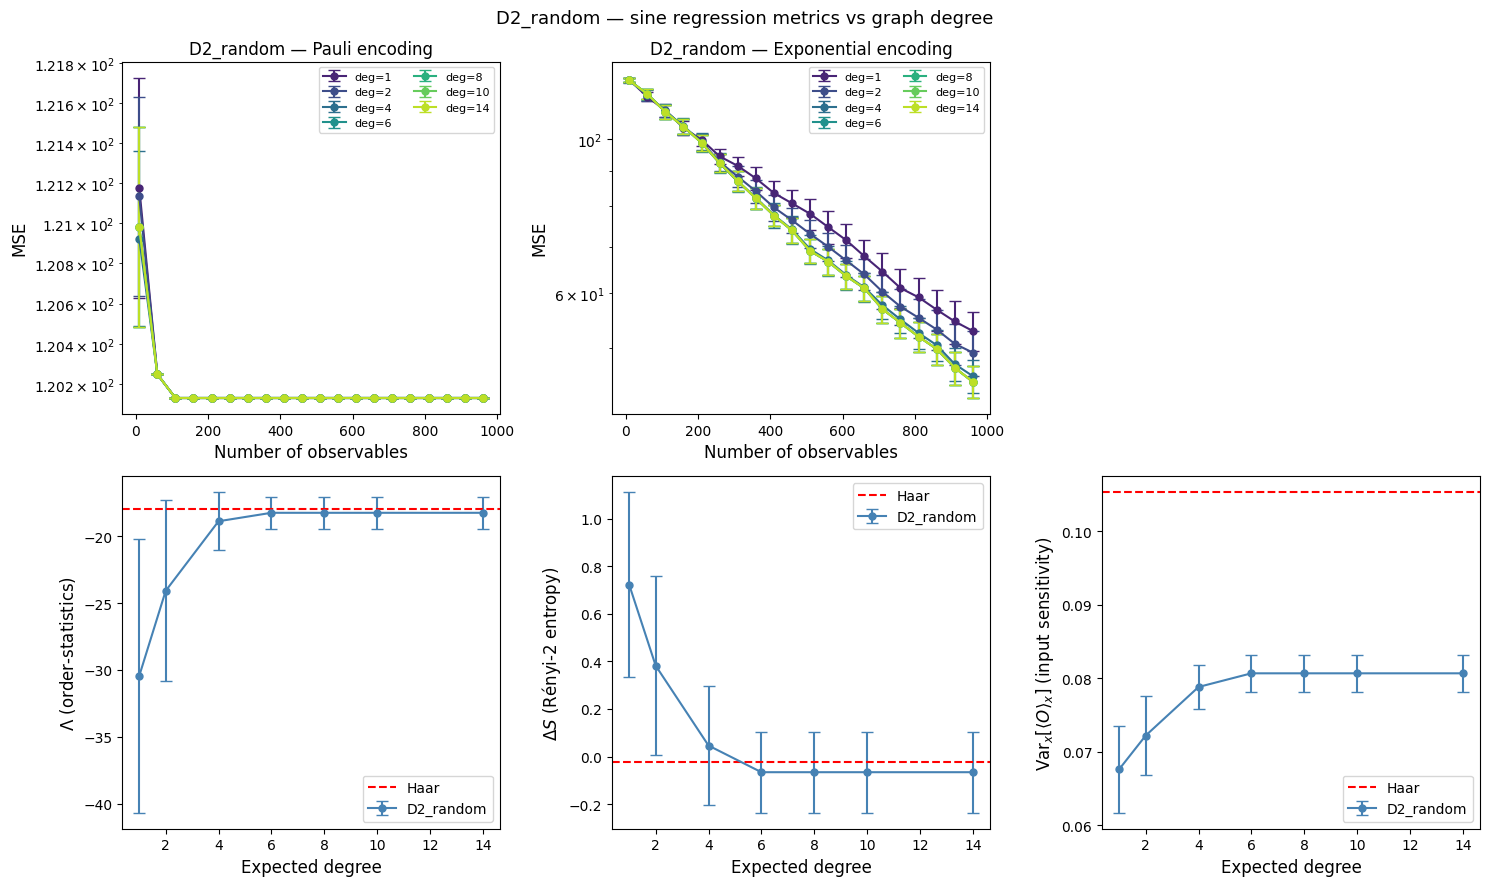

In [119]:
# ── D2_random: MSE curves + scalar metrics vs degree ────────────────────────────
cmap_d2 = plt.cm.viridis
colors_d2 = [cmap_d2(v) for v in np.linspace(0.1, 0.9, len(degrees_sine))]
haar_m_p, haar_s_p = results_sine_Haar['mse_pauli'].mean(axis=0), results_sine_Haar['mse_pauli'].std(axis=0)
haar_m_e, haar_s_e = results_sine_Haar['mse_exp'].mean(axis=0), results_sine_Haar['mse_exp'].std(axis=0)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: MSE vs n_obs for Pauli and Exponential
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_pauli', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_exp',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for deg, color in zip(degrees_sine, colors_d2):
        m, s = results_sine_degree[deg][enc_key].mean(axis=0),results_sine_degree[deg][enc_key].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr = s, color=color, fmt='o-',  capsize=4, ms=5, lw=1.5, label=f'deg={deg}')
        #ax.fill_between(n_obs_list, m - s, m + s, alpha=0.15, color=color)
    #ax.plot(n_obs_list, haar_m, 'r--', lw=1.5, label='Haar')
    #ax.fill_between(n_obs_list, haar_m - haar_s, haar_m + haar_s, alpha=0.12, color='red')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(f'D2_random — {enc_label}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.set_yscale('log')

# Hide unused top-right panel
axes[0, 2].set_visible(False)

# Bottom row: scalar complexity metrics vs degree
haar_scalars = _sine_scalar(results_sine_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col]
    means = np.array([_sine_scalar(results_sine_degree[d])[key].mean() for d in degrees_sine])
    stds  = np.array([_sine_scalar(results_sine_degree[d])[key].std()  for d in degrees_sine])
    ax.errorbar(degrees_sine, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle('D2_random — sine regression metrics vs graph degree', fontsize=13)
plt.tight_layout()
plt.show()


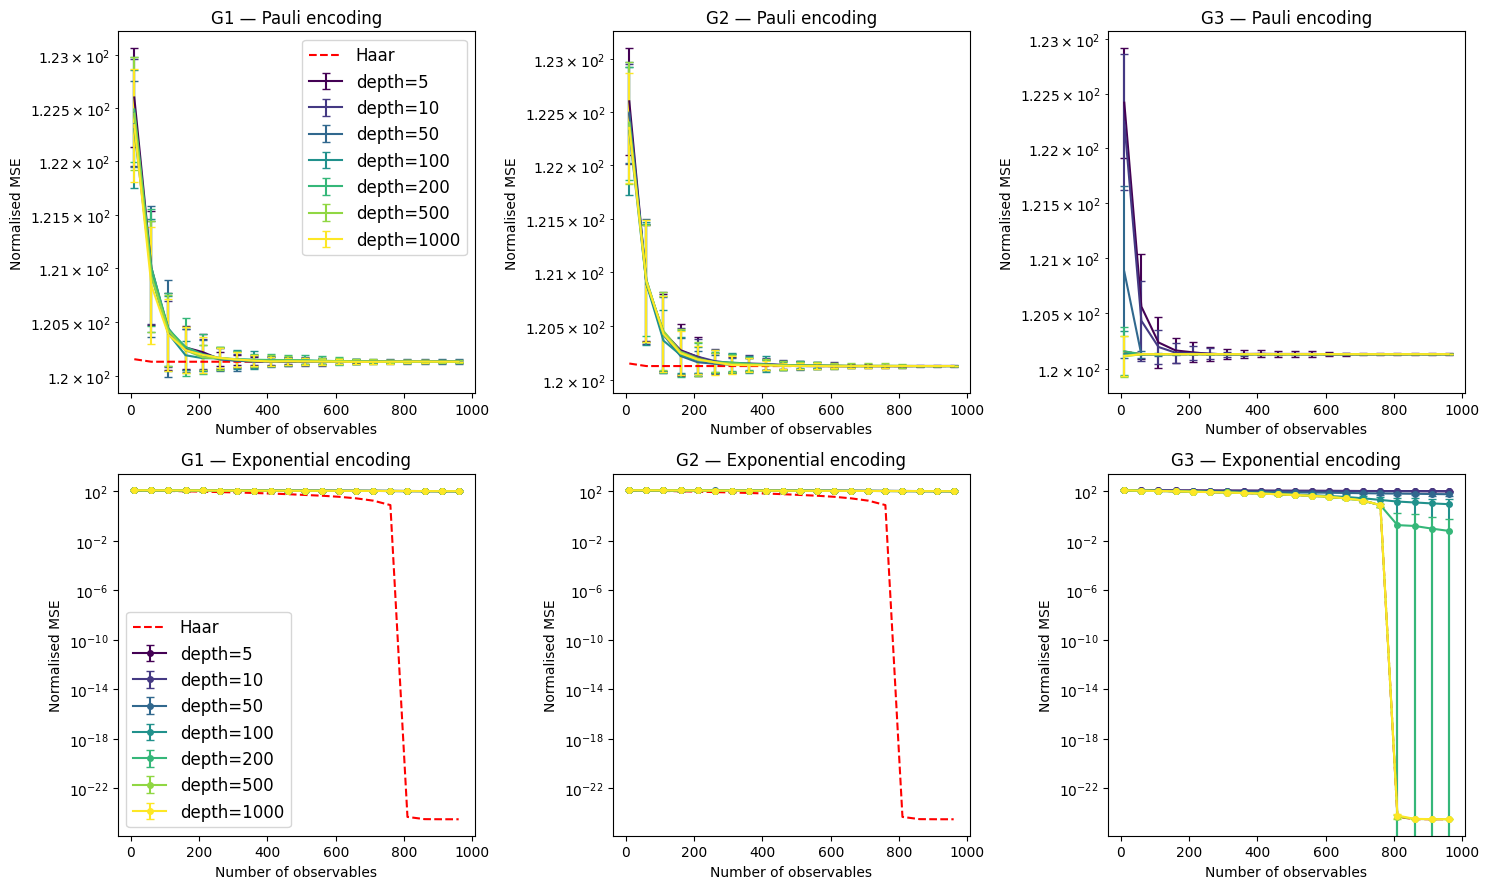

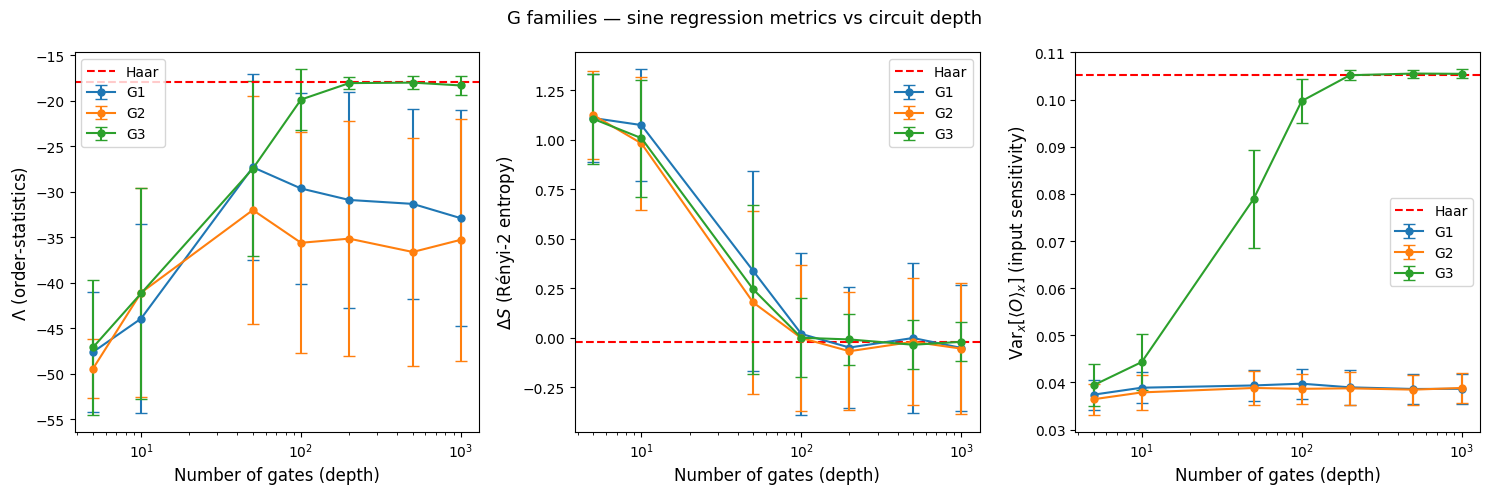

In [120]:
# ── G1/G2/G3: MSE curves + scalar metrics vs depth ──────────────────────────────
colors_g = {"G1": "tab:blue", "G2": "tab:orange", "G3": "tab:green"}
haar_m_p, haar_s_p = results_sine_Haar['mse_pauli'].mean(axis=0), results_sine_Haar['mse_pauli'].std(axis=0)
haar_m_e, haar_s_e = results_sine_Haar['mse_exp'].mean(axis=0), results_sine_Haar['mse_exp'].std(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

cmap_depth = plt.cm.viridis
depth_colors = {d: cmap_depth(i / (len(depths_sine) - 1)) 
                for i, d in enumerate(depths_sine)}

# Top: Pauli encoding, one column per family
for col, family in enumerate(g_fams_sine):
    ax = axes[0, col]
    for depth in depths_sine:
        m = results_sine_depth[family][depth]['mse_pauli'].mean(axis=0)
        s = results_sine_depth[family][depth]['mse_pauli'].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr=s, color=depth_colors[depth],
                    capsize=3, lw=1.5, ms=4, label=f'depth={depth}')
    ax.plot(n_obs_list, haar_m_p, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables')
    ax.set_ylabel('Normalised MSE')
    ax.set_title(f'{family} — Pauli encoding')
    ax.set_yscale('log')
    if col == 0:
        ax.legend(fontsize=12, loc='best')

# Bottom: Exponential encoding, one column per family
for col, family in enumerate(g_fams_sine):
    ax = axes[1, col]
    for depth in depths_sine:
        m = results_sine_depth[family][depth]['mse_exp'].mean(axis=0)
        s = results_sine_depth[family][depth]['mse_exp'].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr=s, color=depth_colors[depth],
                    fmt='o-', capsize=3, lw=1.5, ms=4, label=f'depth={depth}')
    ax.plot(n_obs_list, haar_m_e, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables')
    ax.set_ylabel('Normalised MSE')
    ax.set_title(f'{family} — Exponential encoding')
    ax.set_yscale('log')
    if col == 0:
        ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bottom row: scalar complexity metrics vs depth
haar_scalars = _sine_scalar(results_sine_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[col]
    for family in g_fams_sine:
        means = np.array([_sine_scalar(results_sine_depth[family][d])[key].mean()
                          for d in depths_sine])
        stds  = np.array([_sine_scalar(results_sine_depth[family][d])[key].std()
                          for d in depths_sine])
        ax.errorbar(depths_sine, means, yerr=stds, fmt='o-',
                    color=colors_g[family], capsize=4, lw=1.5, ms=5, label=family)
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xscale('log')
    ax.set_xlabel('Number of gates (depth)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle('G families — sine regression metrics vs circuit depth', fontsize=13)
plt.tight_layout()
plt.show()

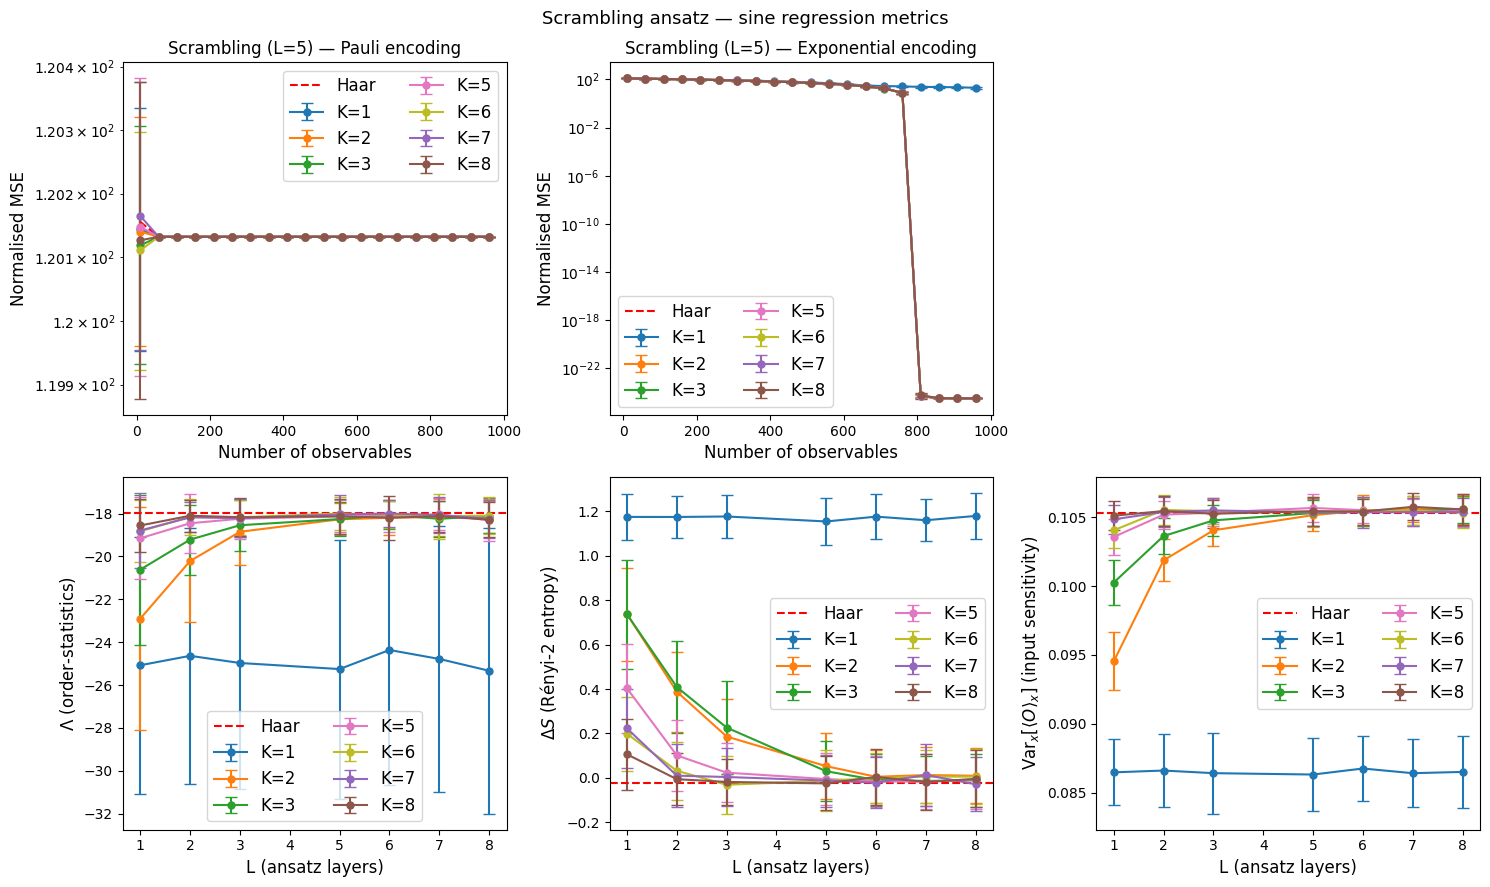

In [121]:
# ── Scrambling ansatz: MSE curves + scalar metrics (L on x-axis, K as colour) ─────
cmap_K = plt.cm.cool
colors_K = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 5: "tab:pink", 6: "tab:olive", 7: "tab:purple", 8: "tab:brown"}
haar_m_p, haar_s_p = results_sine_Haar['mse_pauli'].mean(axis=0), results_sine_Haar['mse_pauli'].std(axis=0)
haar_m_e, haar_s_e = results_sine_Haar['mse_exp'].mean(axis=0), results_sine_Haar['mse_exp'].std(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: MSE vs n_obs for the largest L (L_sine[-1]) and all K values
L_ref = 5#L_sine[-1]   # show the deepest L for clarity
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_pauli', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_exp',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for K_val in K_sine:
        m, s = results_sine_scrambling[(L_ref, K_val)][enc_key].mean(axis=0), results_sine_scrambling[(L_ref, K_val)][enc_key].std(axis=0)#_mse_curve(results_sine_scrambling[(L_ref, K_val)], enc_key)
        ax.errorbar(n_obs_list, m, yerr=s, color=colors_K[K_val], fmt='o-', capsize=4, lw=1.5, ms=5, label=f'K={K_val}')
    ax.plot(n_obs_list, haar_m, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('Normalised MSE', fontsize=12)
    ax.set_title(f'Scrambling (L={L_ref}) — {enc_label}', fontsize=12)
    ax.legend(fontsize=12, ncol=2)
    ax.set_yscale('log')

axes[0, 2].set_visible(False)

# Bottom row: scalar complexity metrics vs L (for all K)
haar_scalars = _sine_scalar(results_sine_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col]
    for K_val in K_sine:
        means = np.array([_sine_scalar(results_sine_scrambling[(L_v, K_val)])[key].mean()
                          for L_v in L_sine])
        stds  = np.array([_sine_scalar(results_sine_scrambling[(L_v, K_val)])[key].std()
                          for L_v in L_sine])
        ax.errorbar(L_sine, means, yerr=stds, fmt='o-',
                    color=colors_K[K_val], capsize=4, lw=1.5, ms=5, label=f'K={K_val}')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('L (ansatz layers)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=12, ncol=2)

fig.suptitle('Scrambling ansatz — sine regression metrics', fontsize=13)
plt.tight_layout()
plt.show()


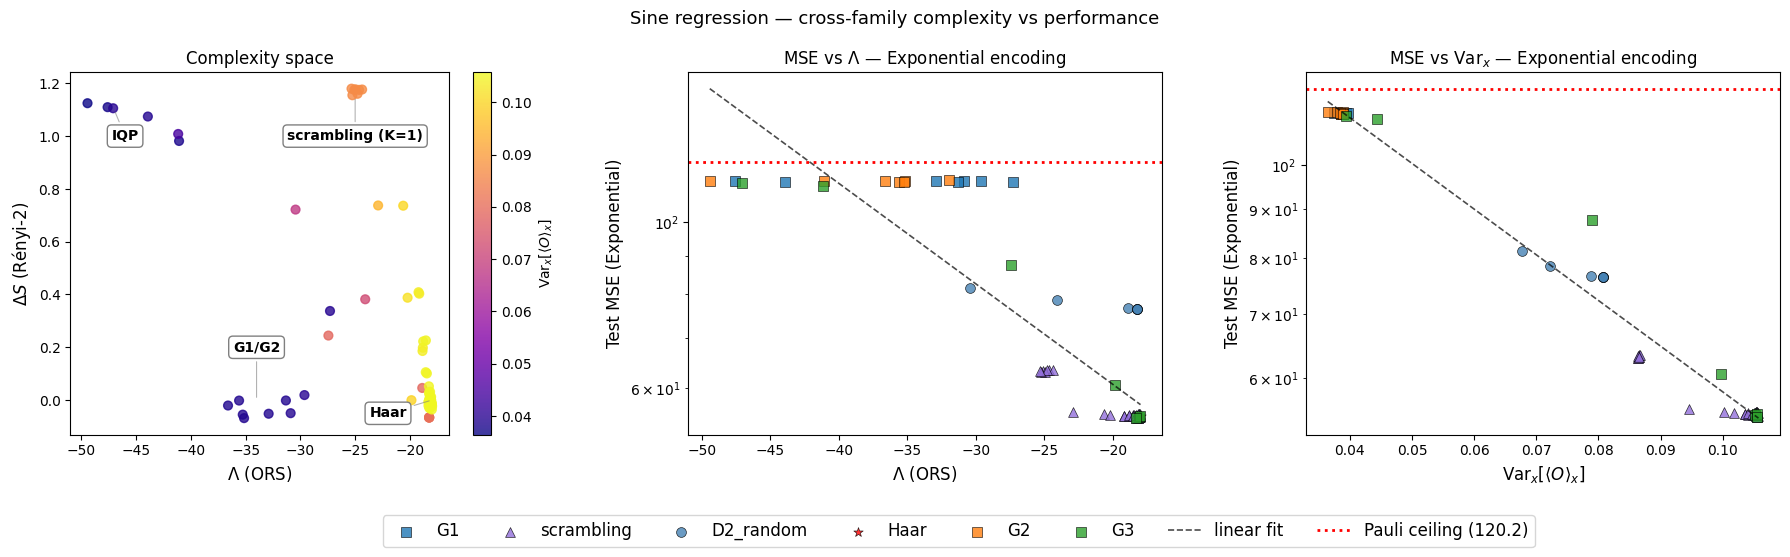


Correlation summary:
  log(MSE_exp) vs Λ:      R² = 0.770, slope = -0.013
  log(MSE_exp) vs Var_x:  R² = 0.985, slope = -4.763


In [112]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# ── Cross-family scatter: complexity vs performance ──────────────────────────
# Build flat list: one point per (family, hyperparameter) configuration
_pts = []

# Haar
sc = _sine_scalar(results_sine_Haar)
_pts.append({'label': 'Haar', 'family': 'Haar',
             'ors': sc['ors'].mean(), 'delta_s': sc['delta_s'].mean(),
             'var_x': sc['var_x'].mean(),
             'mse_p': results_sine_Haar['mse_pauli'].mean(),
             'mse_e': results_sine_Haar['mse_exp'].mean()})

# D2_random
for deg in degrees_sine:
    sc = _sine_scalar(results_sine_degree[deg])
    _pts.append({'label': f'D2 d={deg}', 'family': 'D2_random',
                 'ors': sc['ors'].mean(), 'delta_s': sc['delta_s'].mean(),
                 'var_x': sc['var_x'].mean(),
                 'mse_p': results_sine_degree[deg]['mse_pauli'].mean(),
                 'mse_e': results_sine_degree[deg]['mse_exp'].mean()})

# G families
for family in g_fams_sine:
    for depth in depths_sine:
        sc = _sine_scalar(results_sine_depth[family][depth])
        _pts.append({'label': f'{family} d={depth}', 'family': family,
                     'ors': sc['ors'].mean(), 'delta_s': sc['delta_s'].mean(),
                     'var_x': sc['var_x'].mean(),
                     'mse_p': results_sine_depth[family][depth]['mse_pauli'].mean(),
                     'mse_e': results_sine_depth[family][depth]['mse_exp'].mean()})

# Scrambling
for L_val in L_sine:
    for K_val in K_sine:
        sc = _sine_scalar(results_sine_scrambling[(L_val, K_val)])
        _pts.append({'label': f'Sc L={L_val} K={K_val}', 'family': 'scrambling',
                     'ors': sc['ors'].mean(), 'delta_s': sc['delta_s'].mean(),
                     'var_x': sc['var_x'].mean(),
                     'mse_p': results_sine_scrambling[(L_val, K_val)]['mse_pauli'].mean(),
                     'mse_e': results_sine_scrambling[(L_val, K_val)]['mse_exp'].mean()})

_family_colors = {'Haar': 'red', 'D2_random': 'steelblue',
                  'G1': 'tab:blue', 'G2': 'tab:orange', 'G3': 'tab:green',
                  'scrambling': 'mediumpurple'}
_marker = {'Haar': '*', 'D2_random': 'o', 'G1': 's', 'G2': 's', 'G3': 's',
           'scrambling': '^'}

ors_arr   = np.array([p['ors']     for p in _pts])
ds_arr    = np.array([p['delta_s'] for p in _pts])
vx_arr    = np.array([p['var_x']   for p in _pts])
mse_p_arr = np.array([p['mse_p']   for p in _pts])
mse_e_arr = np.array([p['mse_e']   for p in _pts])

# Pauli ceiling: average across all families (they're all at the baseline anyway)
pauli_ceiling = mse_p_arr.mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── Panel 1: Complexity space with family annotations ──────────────────────
ax = axes[0]
sc_plot = ax.scatter(ors_arr, ds_arr, c=vx_arr, cmap='plasma', s=40, alpha=0.8)
plt.colorbar(sc_plot, ax=ax, label=r'$\mathrm{Var}_x[\langle O\rangle_x]$')
ax.set_xlabel(r'$\Lambda$ (ORS)', fontsize=12)
ax.set_ylabel(r'$\Delta S$ (Rényi-2)', fontsize=12)
ax.set_title('Complexity space', fontsize=12)

# Manual placement: (label_x_offset, label_y_offset) in axes data coords
# Adjust these offsets based on where your clusters actually land
label_offsets = {
    'G1/G2':          ( -34,  0.0),   # cover all three G families
    'Haar':       ( -18, 0),
    'D2_random':  ( 0,  0),
    'scrambling (K=1)': (-25, 1.15),
    'IQP': (-47, 1.1),
}
label_offsets_d = {
    'G1/G2':          (0,  0.2),   # cover all three G families
    'Haar':       ( -4, -0.05),
    'D2_random':  ( 0,  0),
    'scrambling (K=1)': (0, -0.15),
    'IQP': (1, -0.1),
}

fam_display = {'G1': 'G1/G2', 'G2': 'G', 'D2_random':'IQP', 'scrambling':'scrambling (K=1)' }  

_drawn = set()
for fam in set(p['family'] for p in _pts):
    display = fam_display.get(fam, fam)
    if display in _drawn:
        continue
    _drawn.add(display)
    x_mean, y_mean = label_offsets.get(display, (0, 0.2))
    dx, dy = label_offsets_d.get(display, (0, 0.2))
    ax.annotate(display, xy=(x_mean, y_mean), xytext=(x_mean + dx, y_mean + dy),
                fontsize=10, fontweight='bold', color='black',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.6))
    
# ─── Panel 2: MSE vs Λ (exponential) with trend + R² ────────────────────────
ax = axes[1]
for fam in set(p['family'] for p in _pts):
    idx = [j for j, p in enumerate(_pts) if p['family'] == fam]
    ax.scatter(ors_arr[idx], mse_e_arr[idx], color=_family_colors[fam],
               marker=_marker[fam], s=50, alpha=0.8, label=fam, edgecolor='black', lw=0.5)

# Fit log(MSE) ~ Λ and report R²
slope, intercept, r_val, p_val, _ = stats.linregress(ors_arr, np.log10(mse_e_arr))
x_fit = np.linspace(ors_arr.min(), ors_arr.max(), 100)
y_fit = 10 ** (slope * x_fit + intercept)
ax.plot(x_fit, y_fit, 'k--', lw=1.2, alpha=0.7,
        label=f'linear fit ($R^2$={r_val**2:.2f})')

# Pauli baseline (horizontal line)
ax.axhline(pauli_ceiling, color='red', lw=2, ls=':',
           label=f'Pauli ceiling ({pauli_ceiling:.1f})')

ax.set_xlabel(r'$\Lambda$ (ORS)', fontsize=12)
ax.set_ylabel('Test MSE (Exponential)', fontsize=12)
ax.set_title(r'MSE vs $\Lambda$ — Exponential encoding', fontsize=12)
ax.set_yscale('log')

# ─── Panel 3: MSE vs Var_x (exponential) with trend + R² ────────────────────
ax = axes[2]
for fam in set(p['family'] for p in _pts):
    idx = [j for j, p in enumerate(_pts) if p['family'] == fam]
    ax.scatter(vx_arr[idx], mse_e_arr[idx], color=_family_colors[fam],
               marker=_marker[fam], s=50, alpha=0.8, label=fam, edgecolor='black', lw=0.5)

slope_v, intercept_v, r_val_v, _, _ = stats.linregress(vx_arr, np.log10(mse_e_arr))
x_fit = np.linspace(vx_arr.min(), vx_arr.max(), 100)
y_fit = 10 ** (slope_v * x_fit + intercept_v)
ax.plot(x_fit, y_fit, 'k--', lw=1.2, alpha=0.7,
        label=f'linear fit')

ax.axhline(pauli_ceiling, color='red', lw=2, ls=':',
           label=f'Pauli ceiling ({pauli_ceiling:.1f})')

ax.set_xlabel(r'$\mathrm{Var}_x[\langle O\rangle_x]$', fontsize=12)
ax.set_ylabel('Test MSE (Exponential)', fontsize=12)
ax.set_title(r'MSE vs Var$_x$ — Exponential encoding', fontsize=12)
ax.set_yscale('log')

fig.suptitle('Sine regression — cross-family complexity vs performance', fontsize=13)
plt.tight_layout(w_pad=3)

ax.legend(fontsize=12, ncol=8, bbox_to_anchor=(0.5, -0.2))

plt.show()

# Print correlations for quick reference
print(f"\nCorrelation summary:")
print(f"  log(MSE_exp) vs Λ:      R² = {r_val**2:.3f}, slope = {slope:.3f}")
print(f"  log(MSE_exp) vs Var_x:  R² = {r_val_v**2:.3f}, slope = {slope_v:.3f}")

## Conclusions

Key results from the LiH QELM benchmark:
- G3 outperforms G1 at the same gate count, confirming that higher expressivity \(\Lambda\) → higher \(R_{\mathrm{eff}}\) → lower MSE.
- Performance saturates after ~200–500 gates as \(\Lambda\) approaches the Haar limit.
- The D2_random family shows consistently lower performance despite moderate gate count, reflecting its structured (non-Haar) output distribution.
- These results transfer quantitatively to the weather and NARMA benchmarks (Experiment 5).